In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.resource_utils import split_datasets_path
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation.scoring import *

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sklearn\base.py:329: UserWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.1.3. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
data = pd.read_csv(split_datasets_path("bike_bench_mixed_modality.csv"), index_col=0)

In [ ]:
#get any nan indices in data
nan_indices = data[data.isna().any(axis=1)].index

In [ ]:
nan_indices

Int64Index([], dtype='int64')

In [ ]:
import sdv
from sdv.metadata import Metadata  
metadata = Metadata.detect_from_dataframe(
    data=data,
    table_name='my_table'
)
from biked_commons.transformation.one_hot_encoding import ONE_HOT_ENCODED_CLIPS_COLUMNS, BOOLEAN_COLUMNS
categorical_cols = ONE_HOT_ENCODED_CLIPS_COLUMNS
boolean_cols = BOOLEAN_COLUMNS
# # ensure categoricals are flagged
# for col in categorical_cols:
#     metadata.update_column(col, sdtype='categorical')
# metadata.validate()

In [13]:
data_s = data.copy()

data_s = data_s.iloc[:, :9]
metadata_s = Metadata.detect_from_dataframe(
    data=data_s,
    table_name='my_table'
)

In [14]:
from sdv.single_table import GaussianCopulaSynthesizer, TVAESynthesizer, CTGANSynthesizer



# synthesizer = GaussianCopulaSynthesizer(metadata, enforce_rounding = False, enforce_min_max_values=False)
synthesizer = CTGANSynthesizer(metadata_s, verbose=True, epochs=1)

# synthesizer = GaussianCopulaSynthesizer(metadata, enforce_rounding = False, enforce_min_max_values=False, default_distribution='gaussian_kde')
synthesizer.fit(data_s)

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sdv\single_table\base.py:105: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ C:\Users\Lyle\AppData\Local\Temp\ipykernel_24724\436900771.py:9 in <module>                      │
│                                                                                                  │
│ [Errno 2] No such file or directory:                                                             │
│ 'C:\\Users\\Lyle\\AppData\\Local\\Temp\\ipykernel_24724\\436900771.py'                           │
│                                                                                                  │
│ c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sdv\single_table\base.py:532 in fit │
│                                                                                                  │
│    529 │   │   self._data_processor.reset_sampling()                                             │
│    530 │   │   self._random_state_set = False                                                    │
│    531 │   │   processed_data = self.preprocess(data)                                            │
│ ❱  532 │   │   self.fit_processed_data(processed_data)                                           │
│    533 │                                                                                         │
│    534 │   def _validate_fit_before_save(self):                                                  │
│    535 │   │   """Validate that the synthesizer has been fitted before saving."""                │
│                                                                                                  │
│ c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sdv\single_table\base.py:502 in     │
│ fit_processed_data                                                                               │
│                                                                                                  │
│    499 │   │                                                                                     │
│    500 │   │   check_synthesizer_version(self, is_fit_method=True, compare_operator=operator.lt  │
│    501 │   │   if not processed_data.empty:                                                      │
│ ❱  502 │   │   │   self._fit(processed_data)                                                     │
│    503 │   │                                                                                     │
│    504 │   │   self._fitted = True                                                               │
│    505 │   │   self._fitted_date = datetime.datetime.today().strftime('%Y-%m-%d')                │
│                                                                                                  │
│ c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\sdv\single_table\ctgan.py:293 in    │
│ _fit                                                                                             │
│                                                                                                  │
│   290 │   │   self._model = CTGAN(**self._model_kwargs)                                          │
│   291 │   │   with warnings.catch_warnings():                                                    │
│   292 │   │   │   warnings.filterwarnings('ignore', message='.*Attempting to run cuBLAS.*')      │
│ ❱ 293 │   │   │   self._model.fit(processed_data, discrete_columns=discrete_columns)             │
│   294 │                                                                                          │
│   295 │   def _sample(self, num_rows, conditions=None):                                          │
│   296 │   │   """Sample the indicated number of rows from the model.                             │
│                                                                                                  │
│ c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\ctgan\synthesizers\base.py:50 in    │
│ wrapper                                                    

In [ ]:
synthetic_collapsed = synthesizer.sample(num_rows=10000)

In [ ]:
synthetic_collapsed

,CS textfield,BB textfield,Stack,Head angle,Head tube length textfield,Seat stay junction0,Seat tube length,Seat angle,DT Length,FORK0R,...,RIM_STYLE rear,SPOKES composite front,SPOKES composite rear,SBLADEW front,SBLADEW rear,Saddle length,Saddle height,Down tube diameter,Seatpost LENGTH,Seat tube type
0,486.673959,30.074914,511.181279,68.923220,115.034831,65.148849,17.100016,72.293005,608.315891,74.937201,...,SPOKED,1,1,81.975191,74.542444,303.661680,1129.544901,31.588053,10.0,1
1,369.742664,74.589055,541.955753,65.683002,137.353338,84.008346,17.100016,74.102688,687.094261,35.636322,...,SPOKED,1,1,78.650525,64.071259,266.624596,803.792617,35.385482,10.0,1
2,373.397458,50.216506,570.497097,71.615838,151.649153,33.838865,17.100000,68.117707,617.546063,45.264110,...,SPOKED,1,1,67.943613,62.488425,285.876397,462.282668,30.638724,10.0,1
3,450.524168,46.145519,659.952232,76.429117,196.341739,82.924450,17.100013,75.769027,658.140680,37.696777,...,SPOKED,1,1,77.527749,79.457596,336.488663,1148.414729,35.953588,10.0,1
4,363.085863,53.038807,563.072996,71.766515,131.466614,131.878492,17.100013,76.599068,615.991538,26.573796,...,SPOKED,1,1,57.260702,71.014158,270.940150,919.731931,36.039135,10.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,348.324180,-13.075892,462.750086,73.151531,101.676879,138.266935,17.099976,69.360001,542.159652,31.442154,...,SPOKED,1,1,81.404415,85.975754,307.937043,1083.269977,37.944141,10.0,0
9996,451.324034,73.741533,632.685205,71.093186,169.076060,95.023722,17.100004,70.773711,670.398256,33.360105,...,SPOKED,1,1,96.719301,85.440783,312.409045,1119.065670,39.080883,10.0,1
9997,370.957655,27.359964,548.851931,74.574961,120.524247,53.026823,17.099964,73.419315,660.333481,38.836051,...,SPOKED,1,4,64.109609,65.512625,246.424750,1006.748058,35.652457,10.0,1
9998,412.199181,56.861585,599.568134,75.757915,118.214665,27.572380,17.099960,73.265721,771.514795,46.170017,...,SPOKED,1,1,79.581266,79.642267,258.906136,1086.311424,42.164378,10.0,2


In [ ]:
data["Seat tube length"]

1       588.7
2       265.0
3       562.0
4       460.0
5       300.0
        ...  
3768    533.0
3769    518.0
3770    523.4
3771    520.0
3772    580.0
Name: Seat tube length, Length: 3600, dtype: float64

In [ ]:
synthetic_collapsed["Seat tube length"]

0       17.100016
1       17.100016
2       17.100000
3       17.100013
4       17.100013
          ...    
9995    17.099976
9996    17.100004
9997    17.099964
9998    17.099960
9999    17.099981
Name: Seat tube length, Length: 10000, dtype: float64

In [ ]:
data["CHAINSTAYbrdgshift"]


1       350.0
2       350.0
3       350.0
4       350.0
5       350.0
        ...  
3768    350.0
3769    350.0
3770    350.0
3771    350.0
3772    350.0
Name: CHAINSTAYbrdgshift, Length: 3600, dtype: float64

In [ ]:
print(np.min(data["CHAINSTAYbrdgshift"]))

260.0


In [ ]:
data["CHAINSTAYbrdgshift"].nunique()

52

In [ ]:
synthetic_collapsed["CHAINSTAYbrdgshift"]

0      -1022.72067
1      -1022.72067
2      -1022.72067
3      -1022.72067
4      -1022.72067
           ...    
9995   -1022.72067
9996   -1022.72067
9997   -1022.72067
9998   -1022.72067
9999   -1022.72067
Name: CHAINSTAYbrdgshift, Length: 10000, dtype: float64

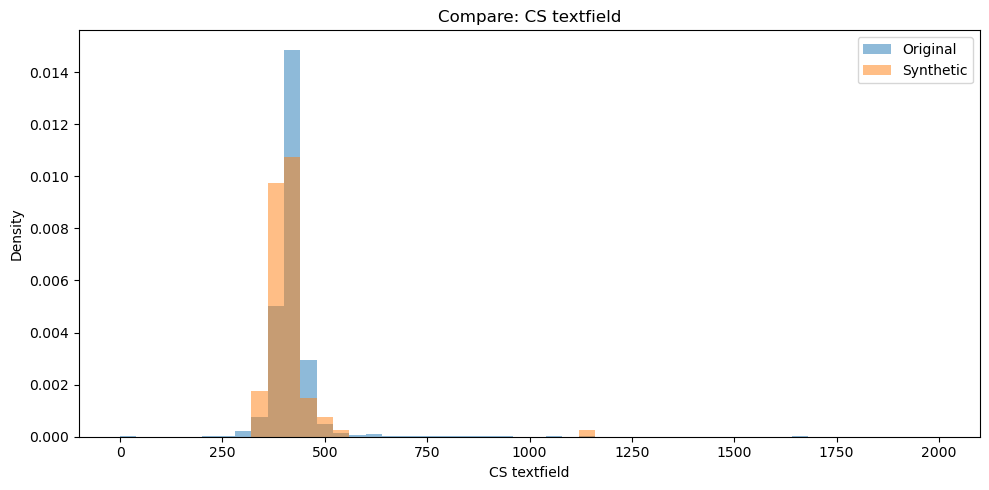

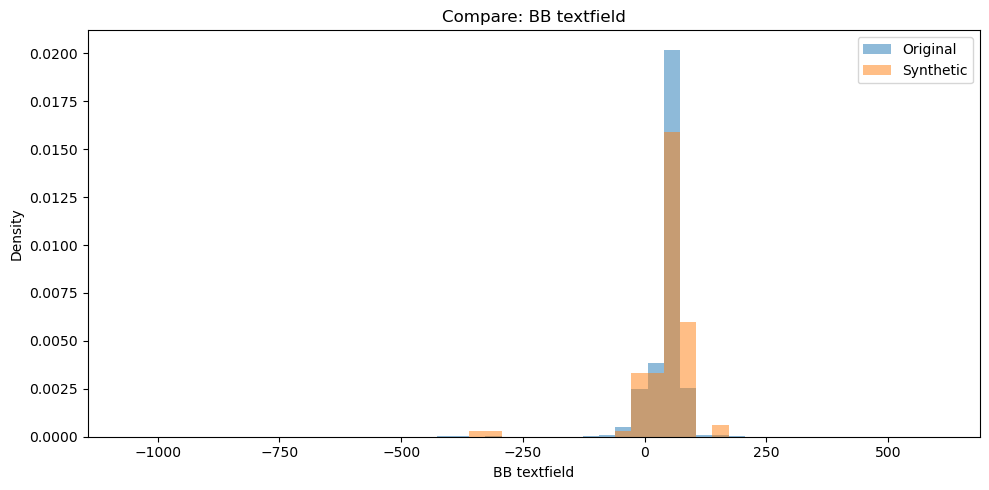

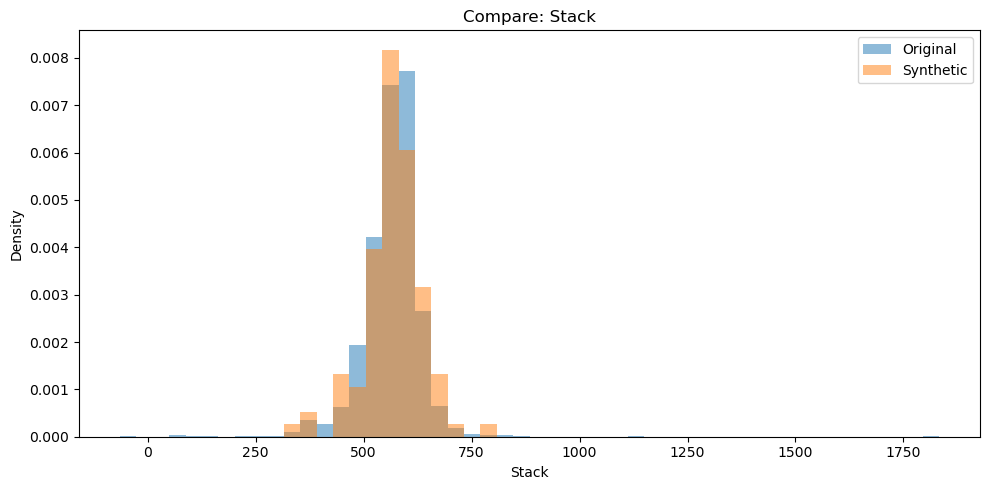

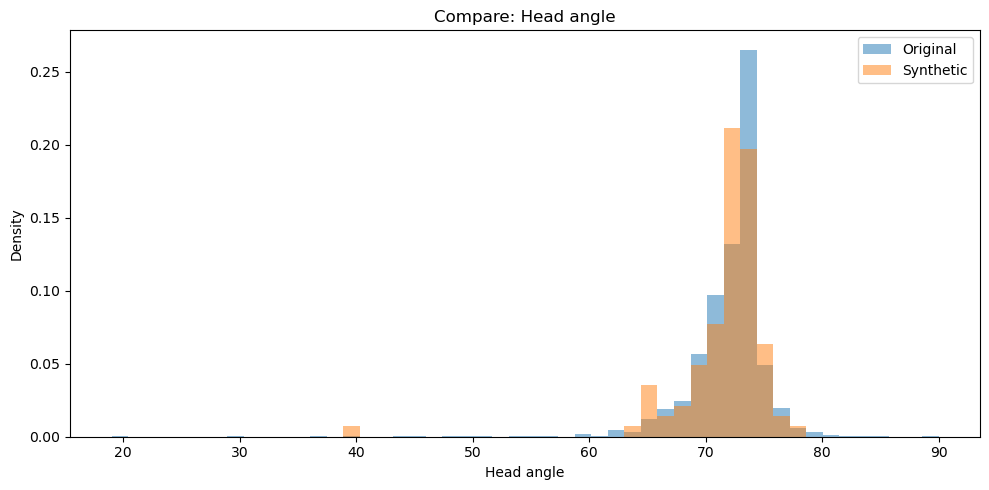

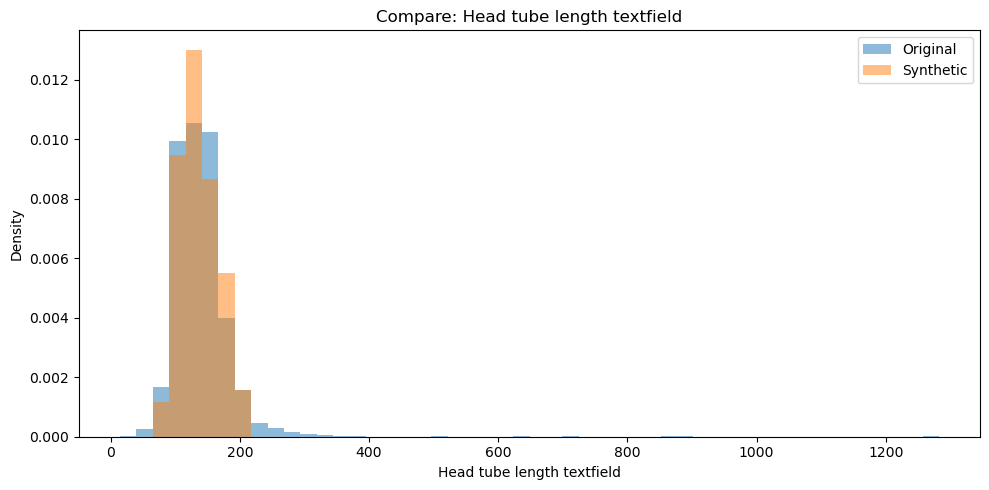

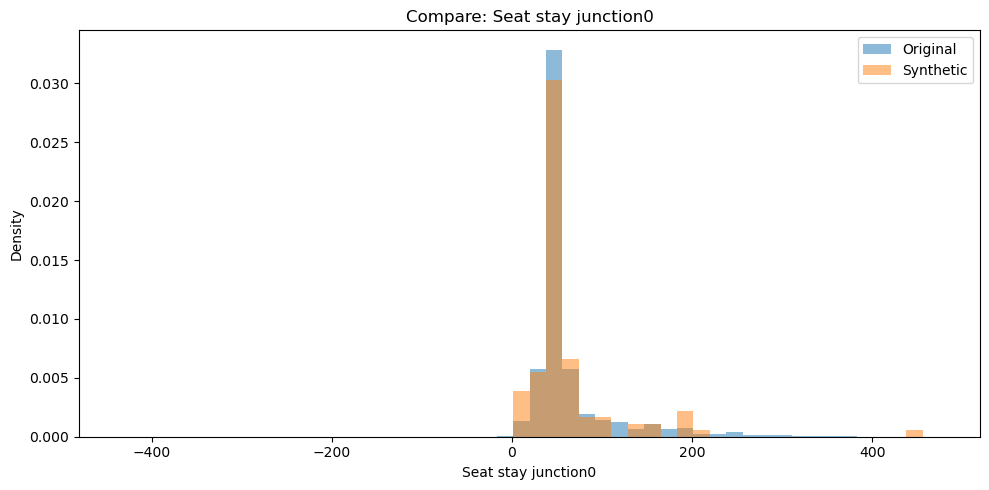

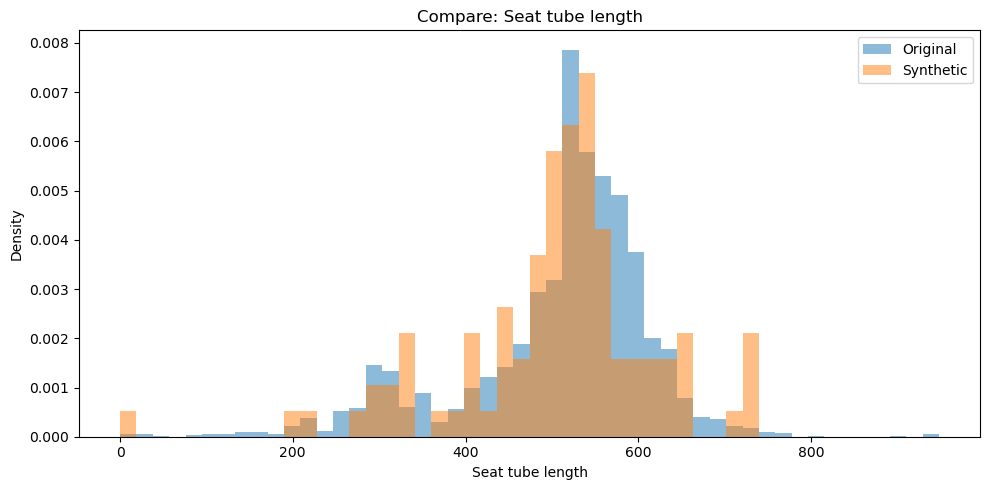

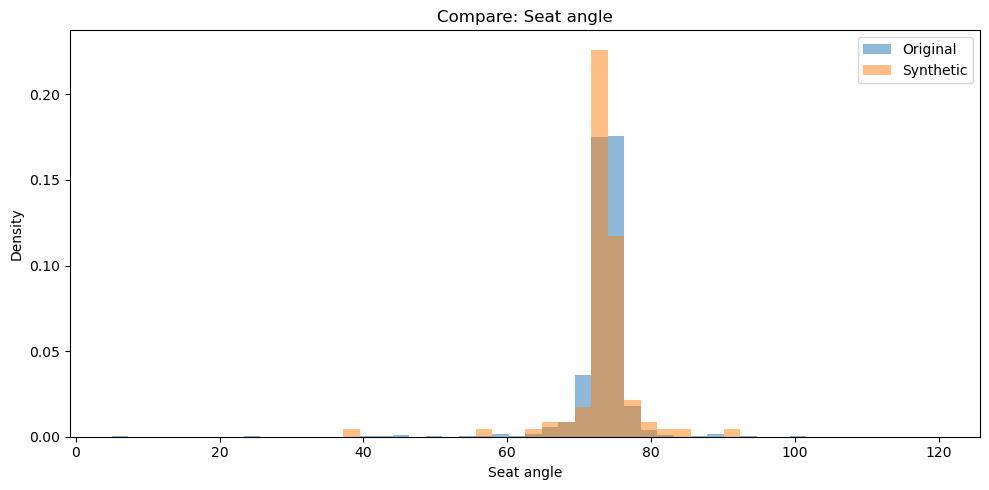

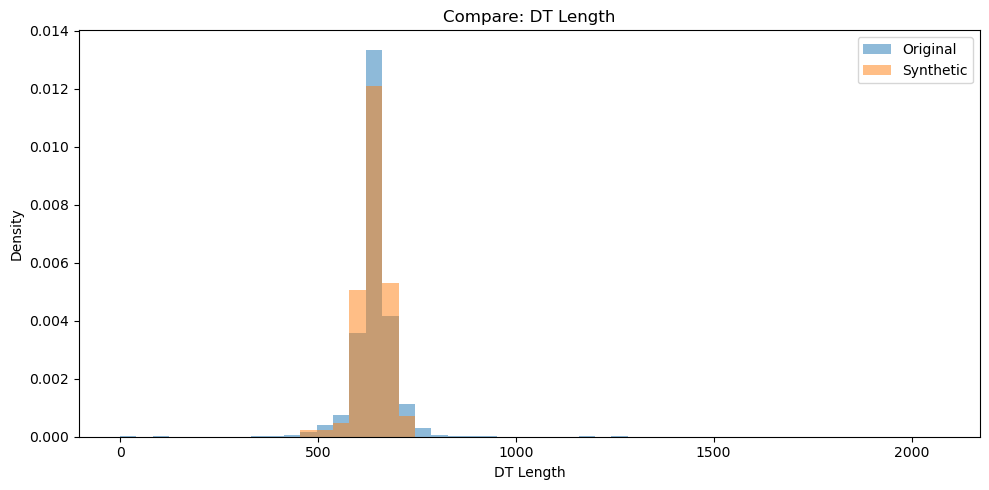

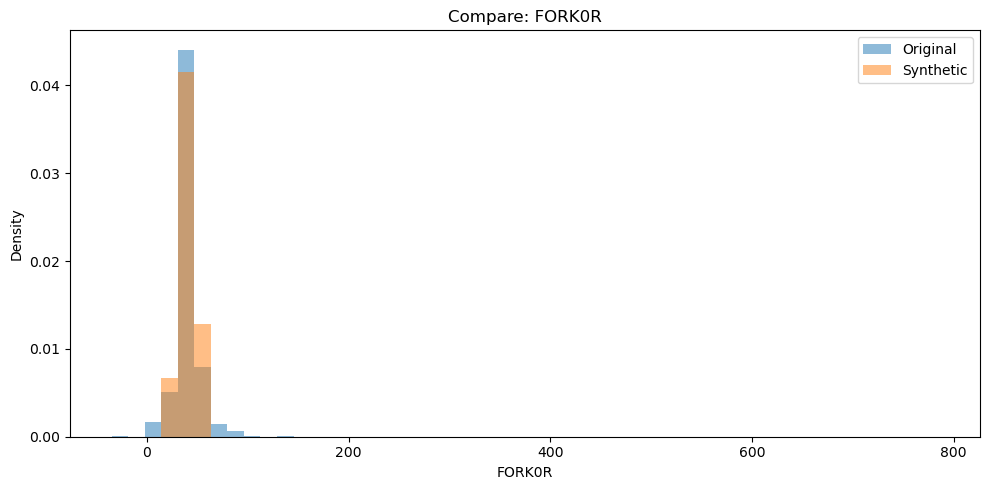

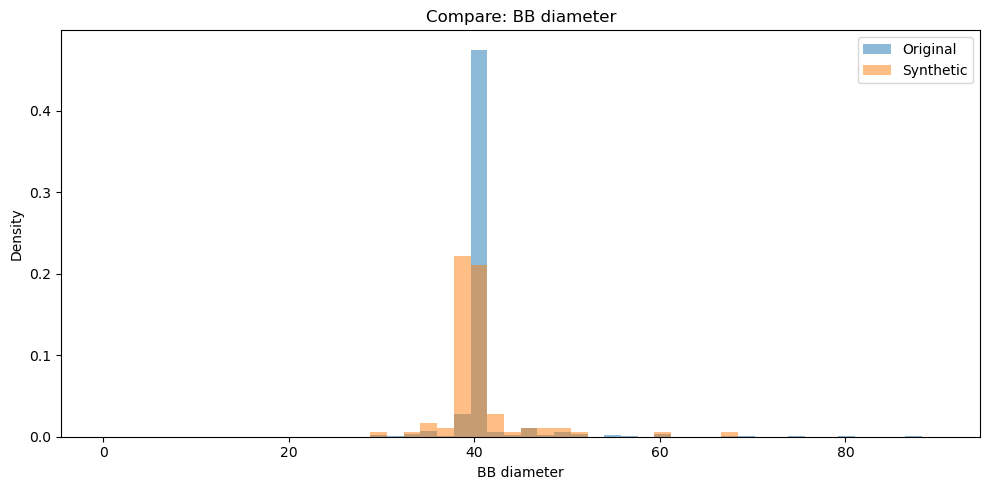

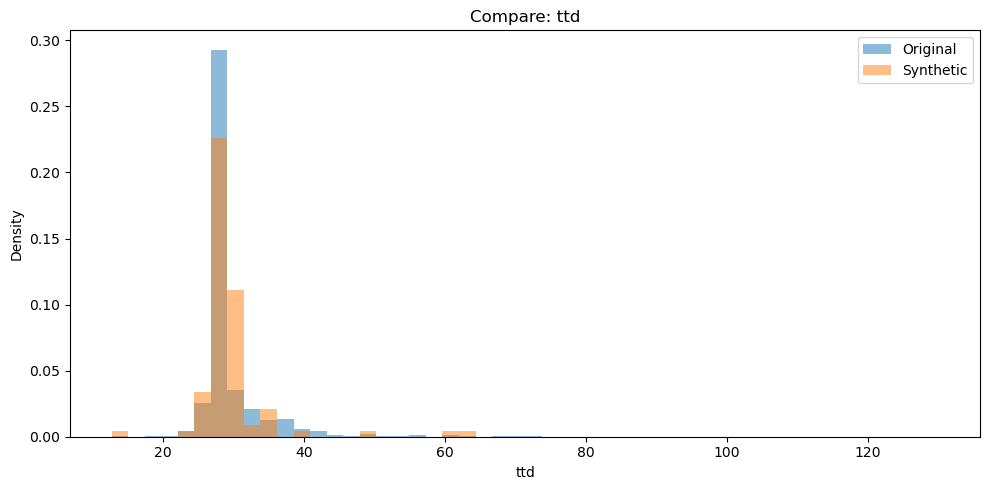

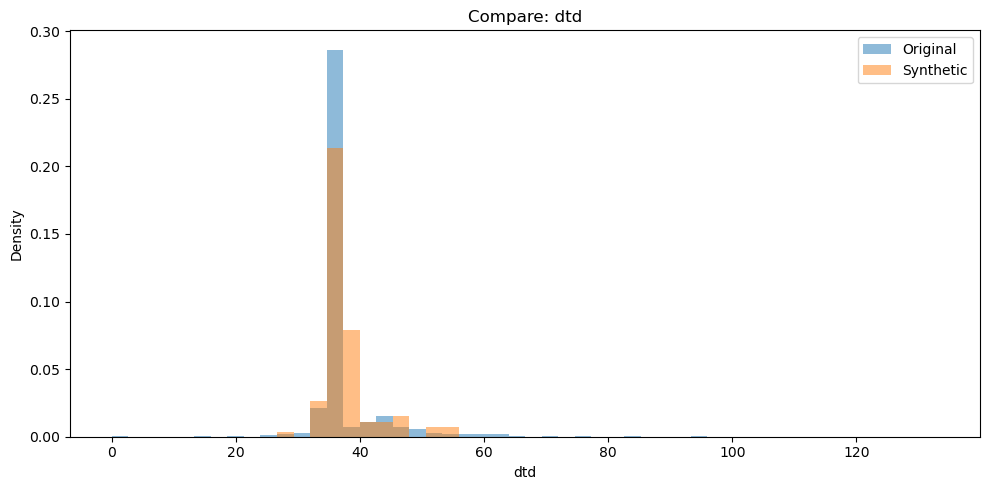

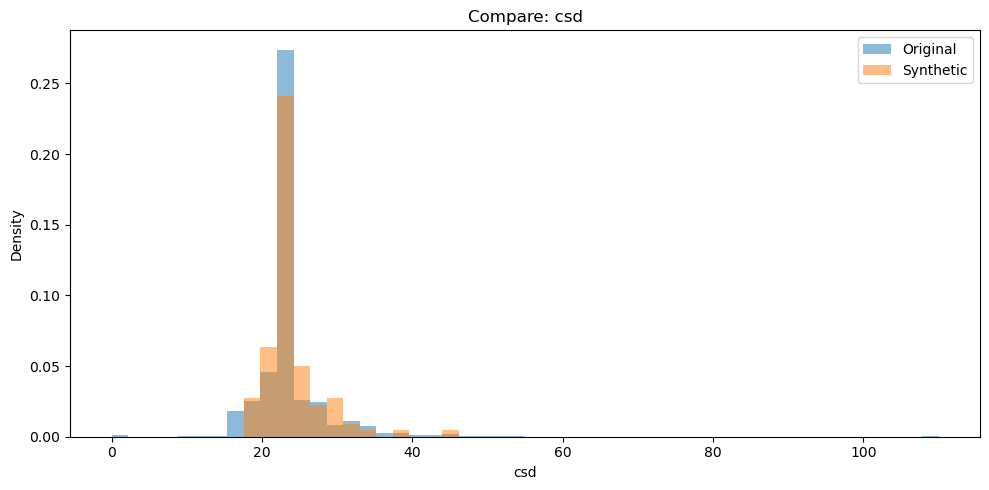

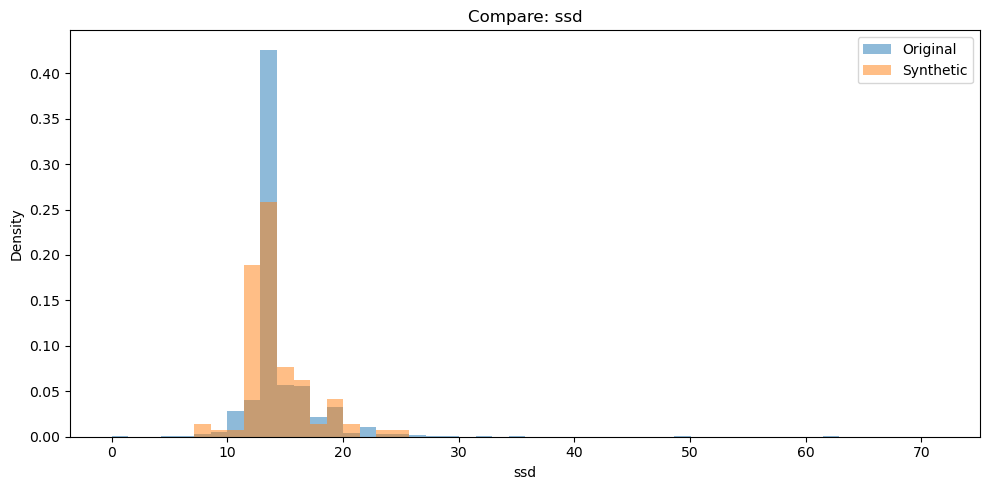

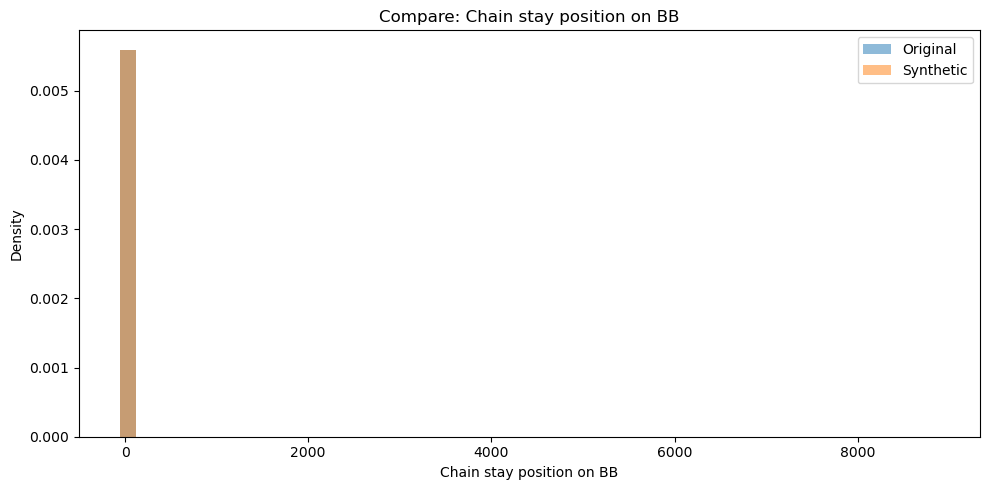

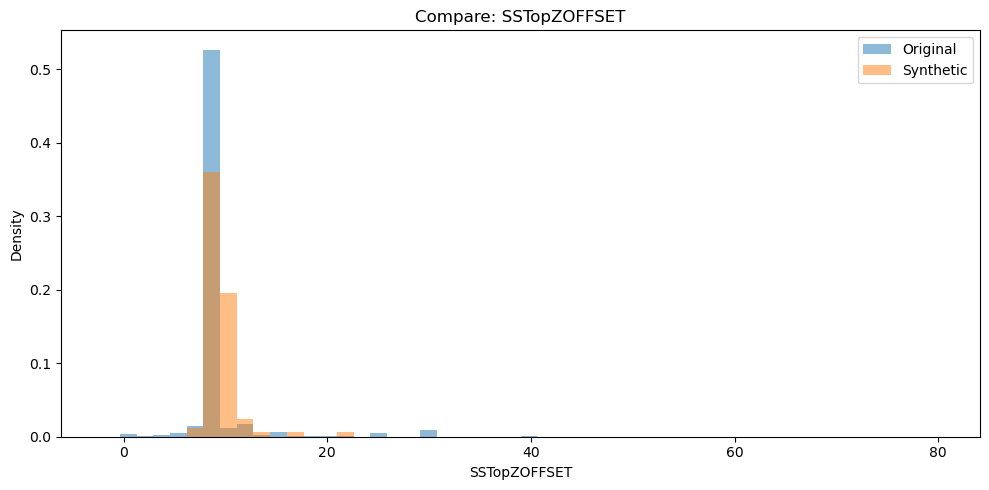

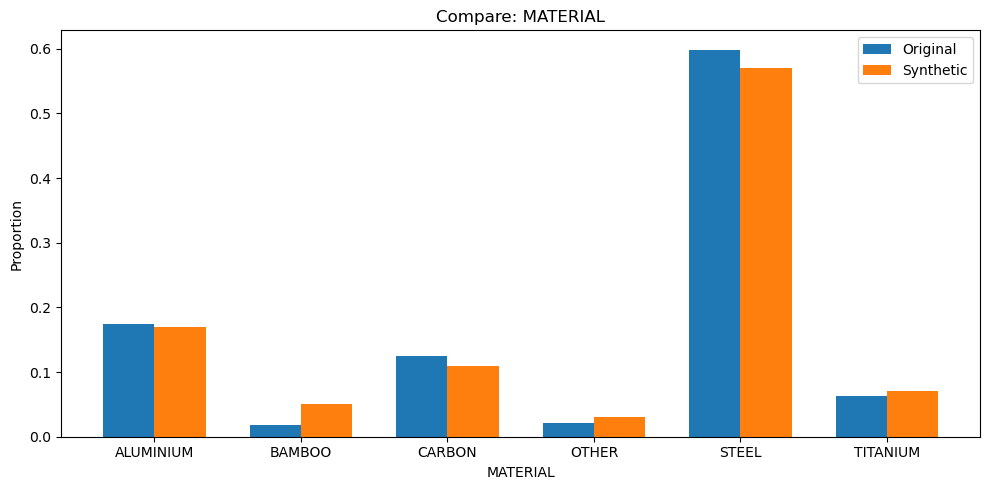

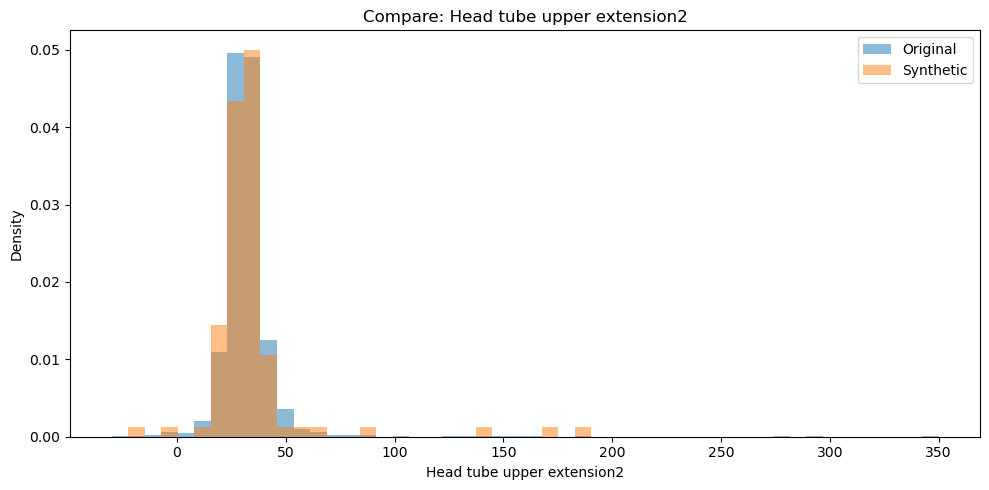

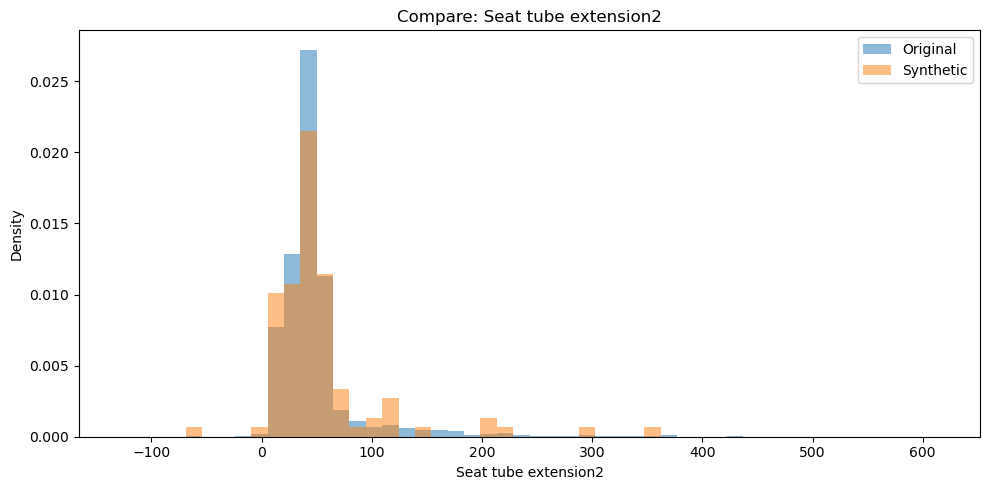

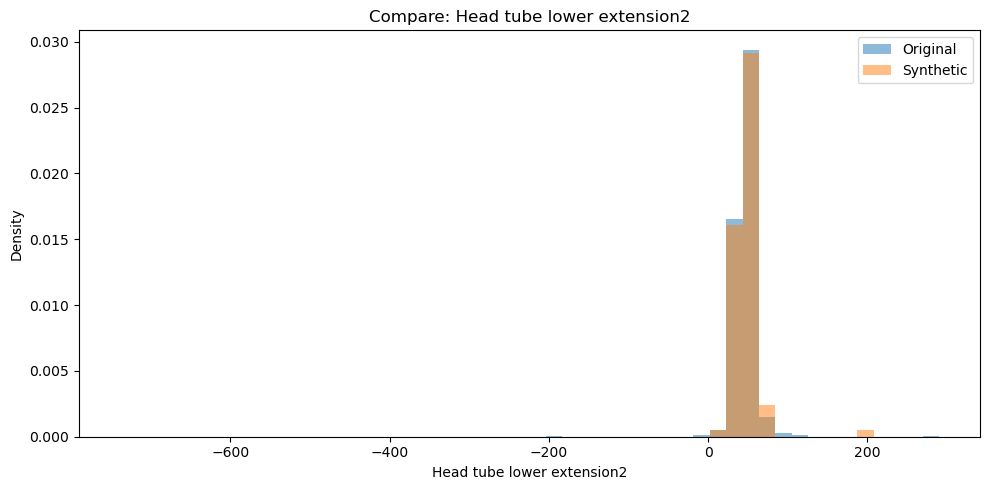

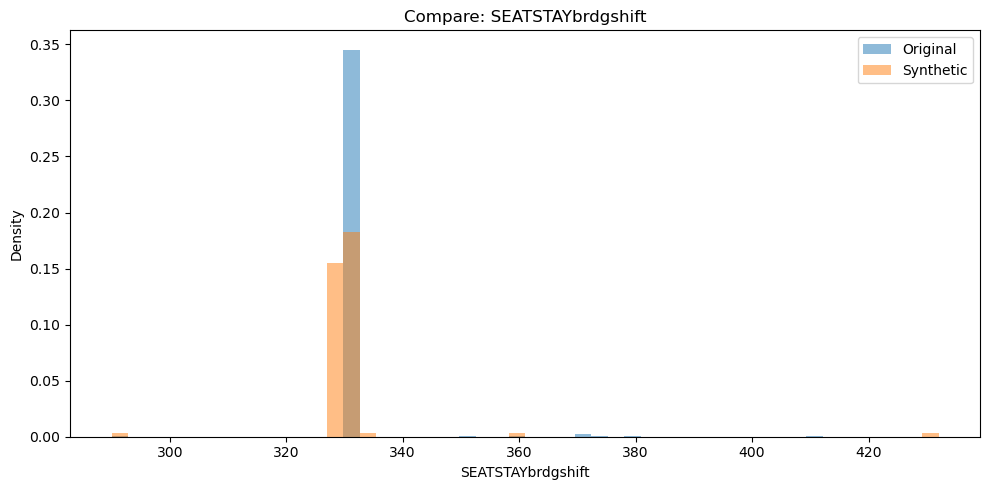

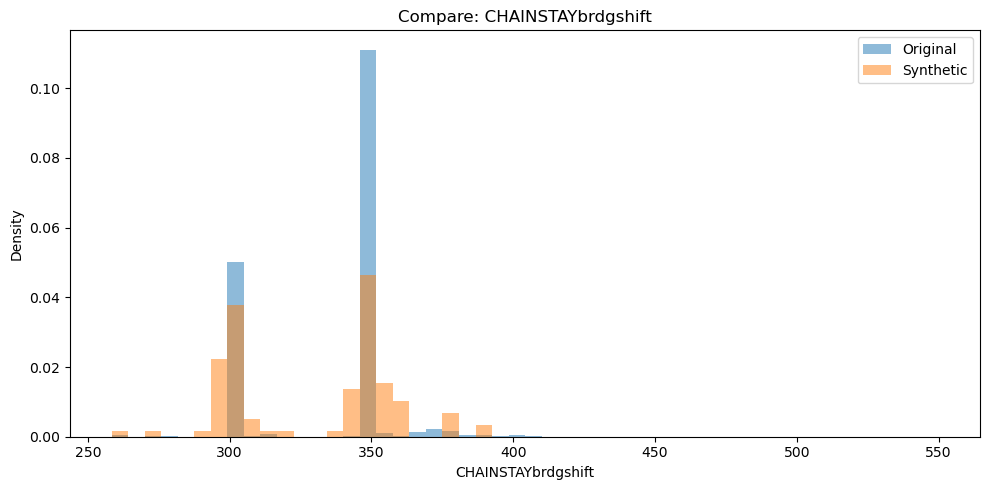

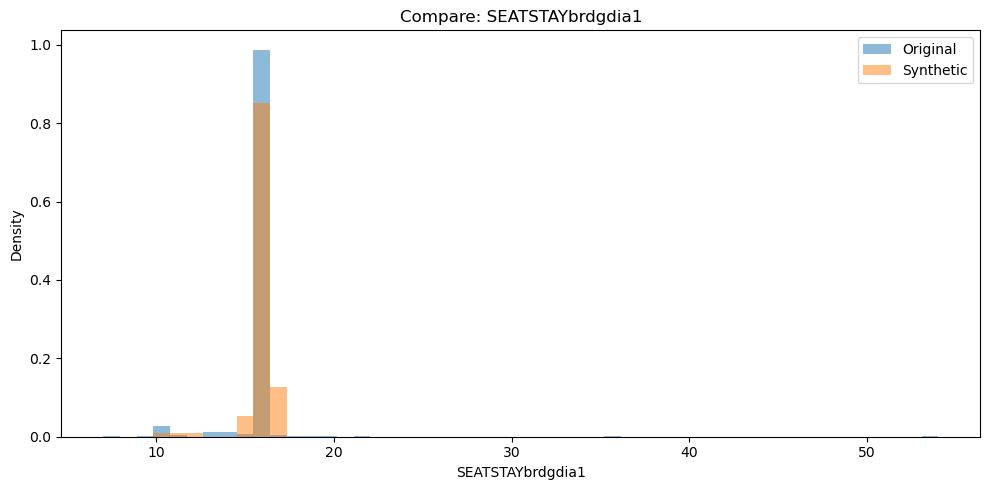

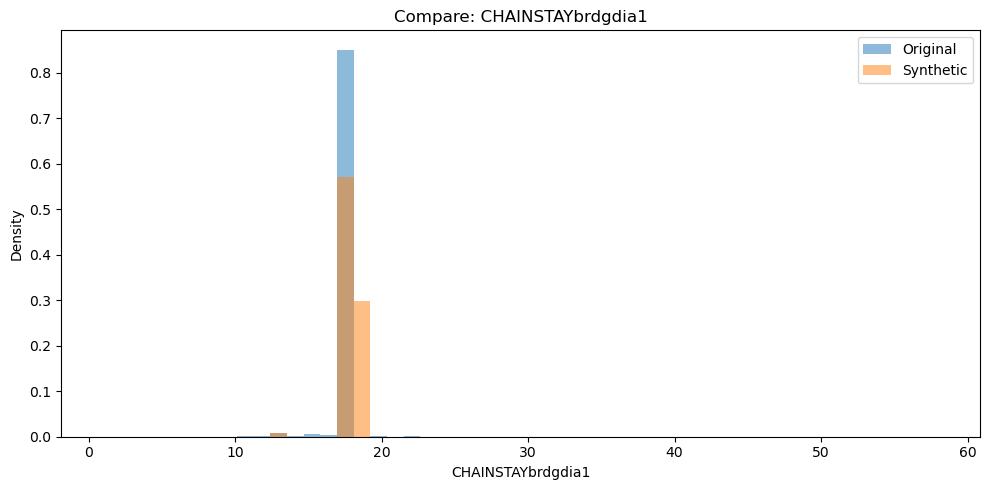

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\matplotlib\axes\_axes.py:6737: RuntimeWarning:

Converting input from bool to <class 'numpy.uint8'> for compatibility.



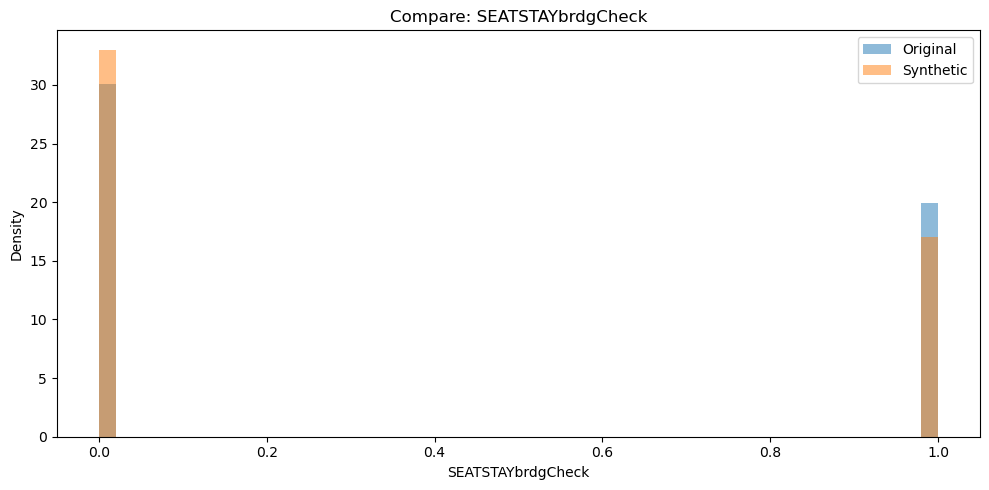

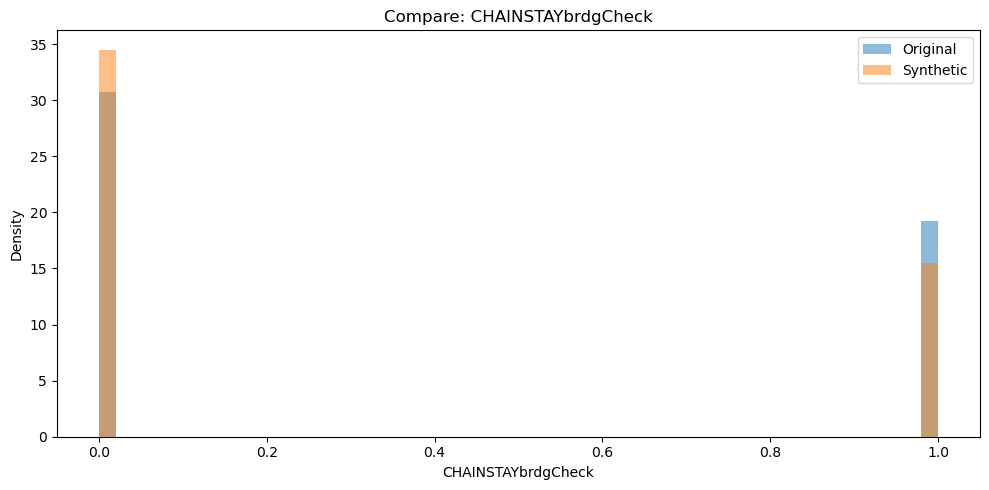

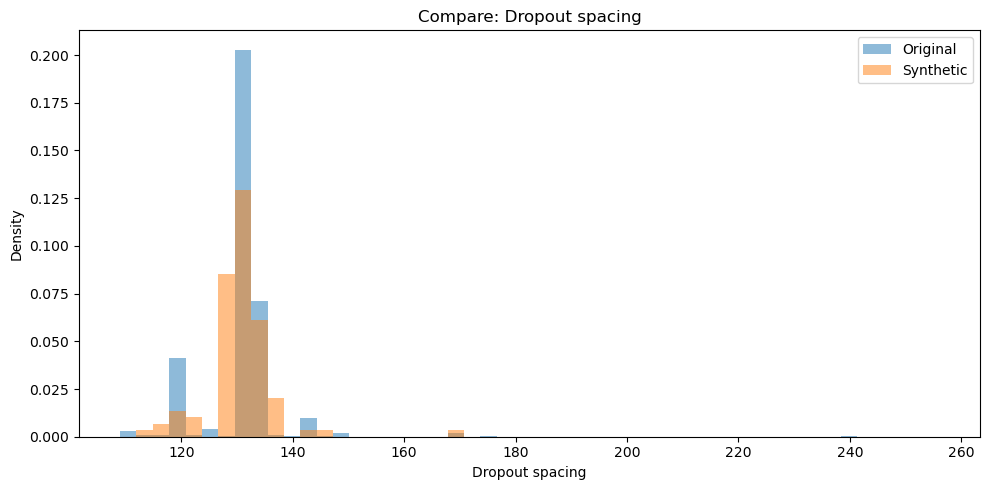

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning:

divide by zero encountered in divide

c:\Users\Lyle\mambaforge\envs\pytorch_clip\lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning:

invalid value encountered in divide



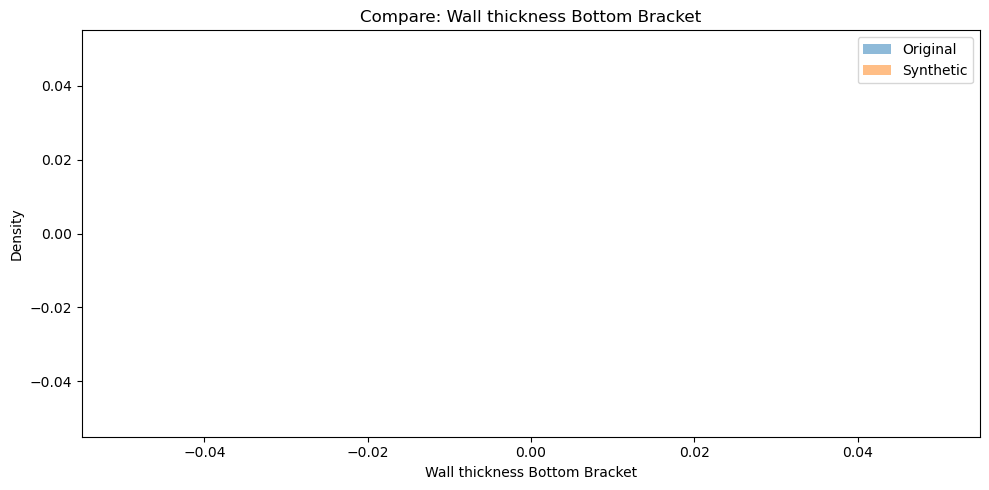

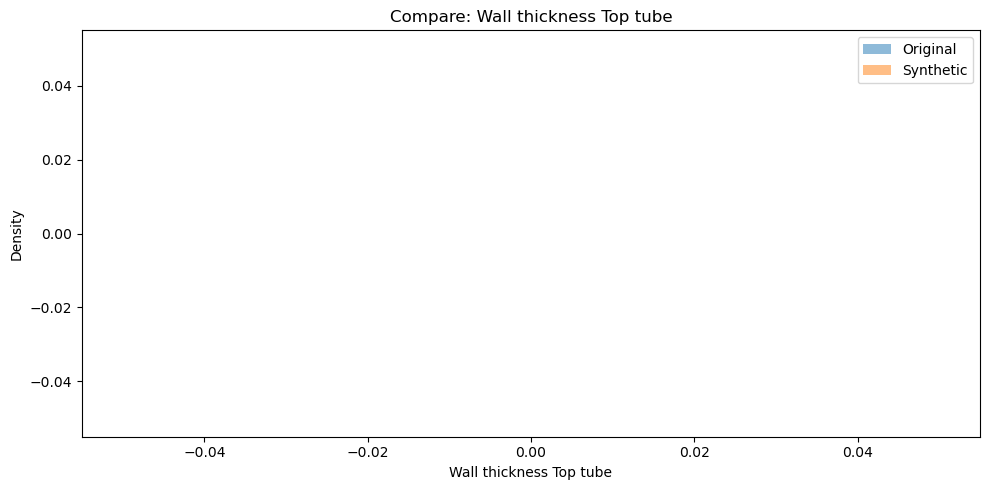

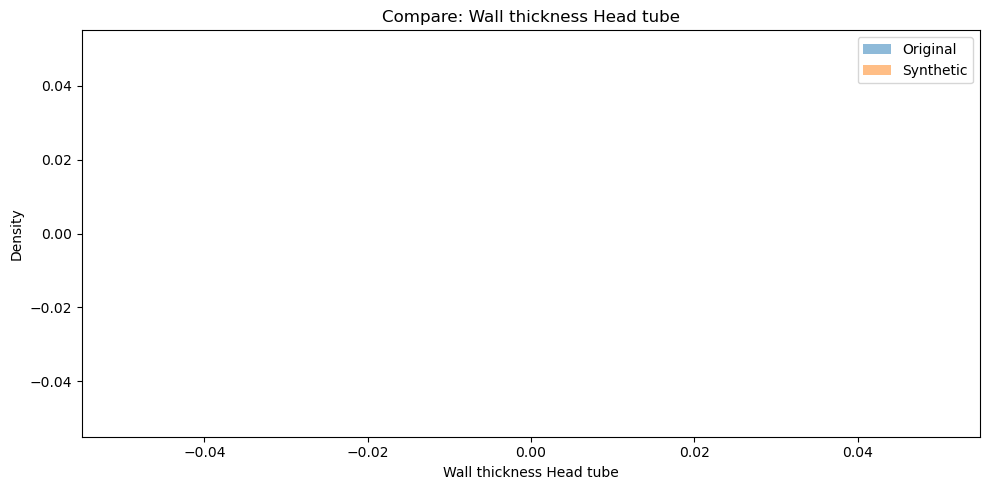

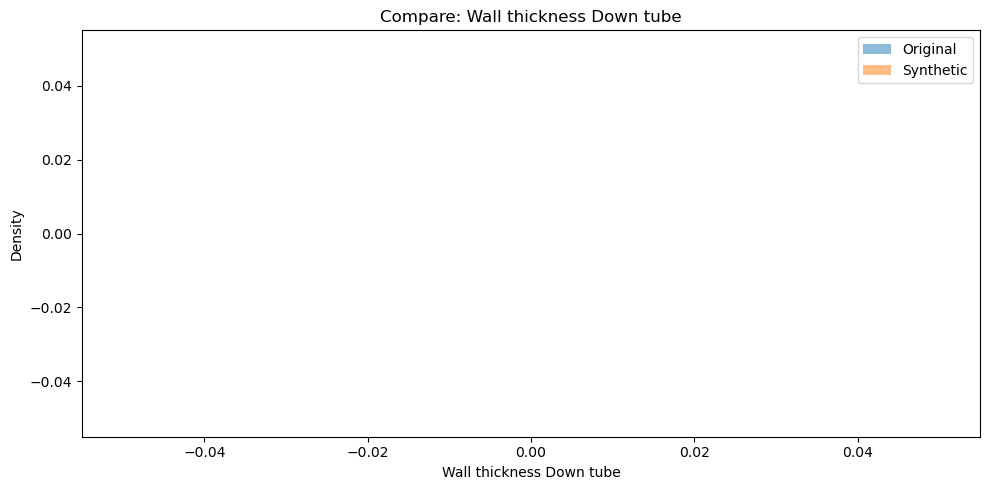

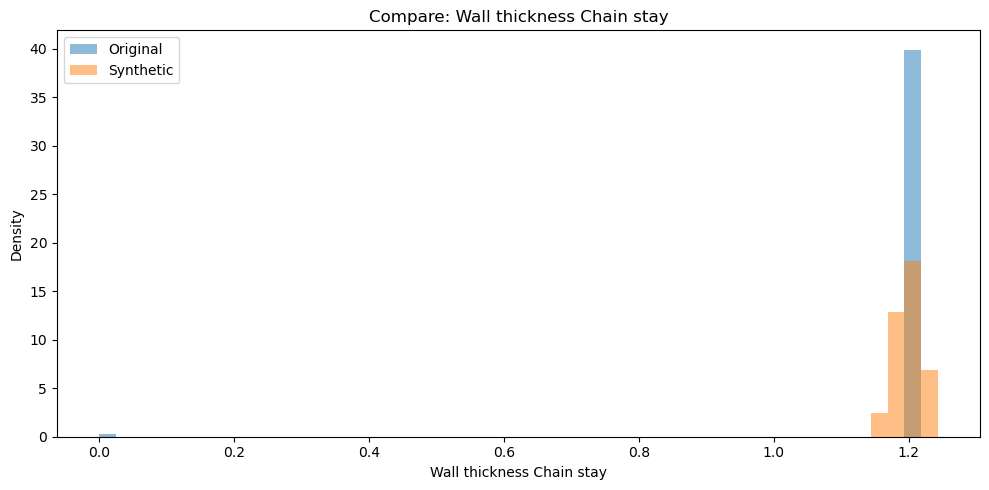

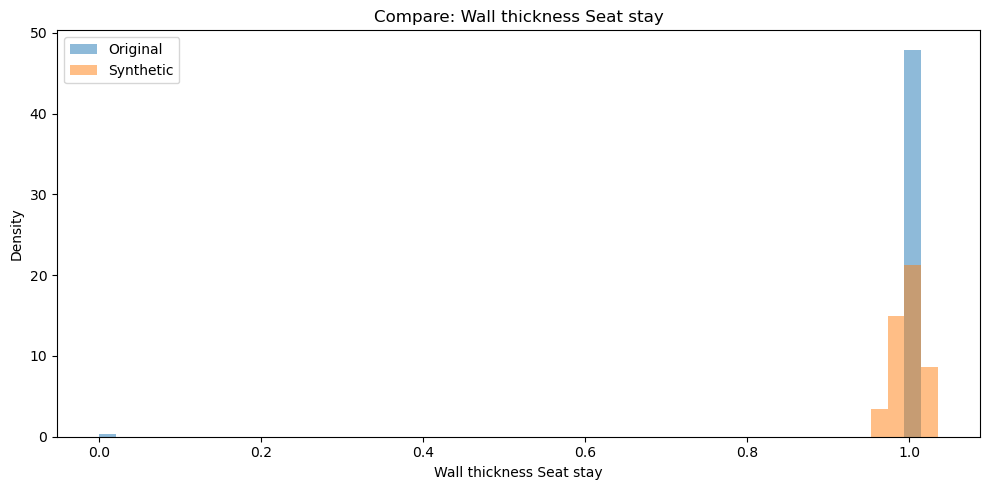

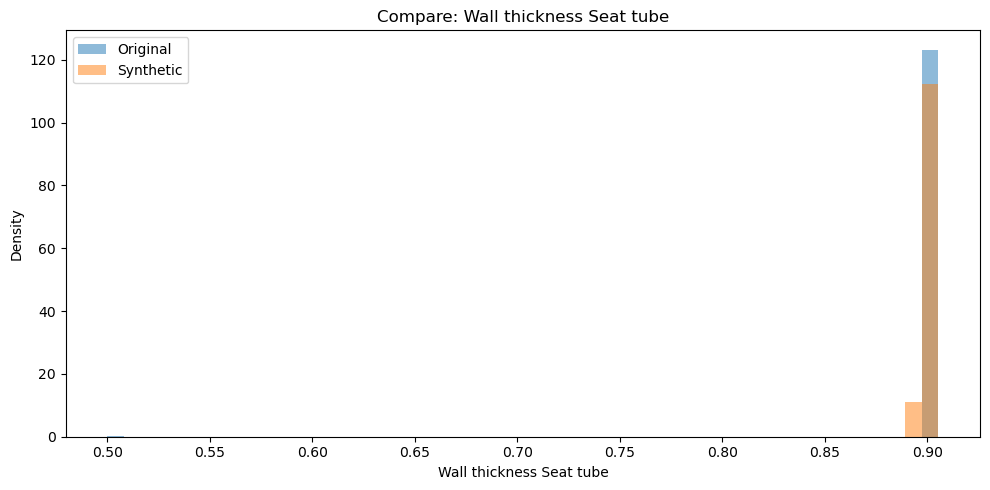

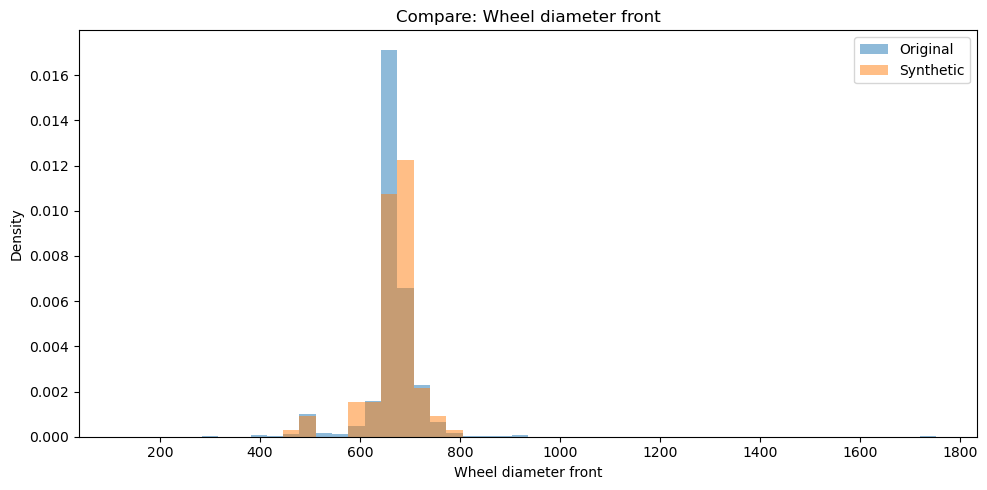

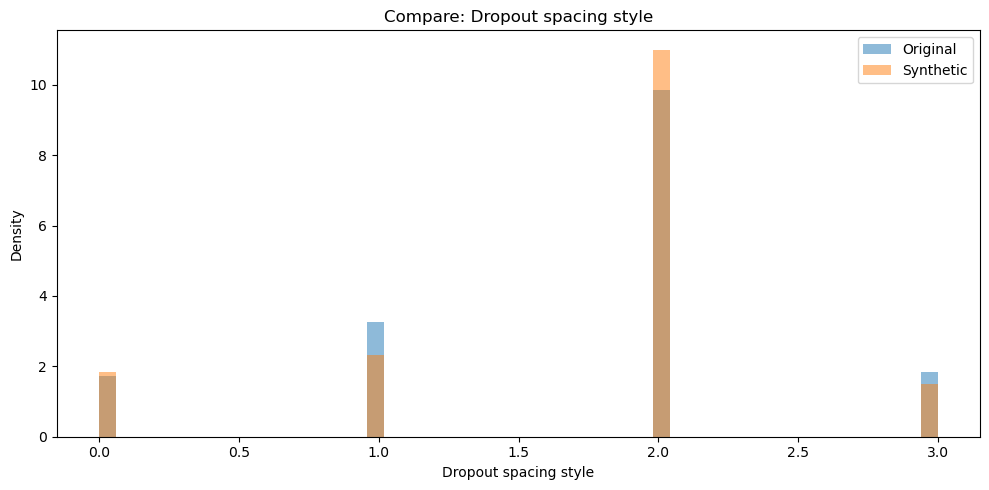

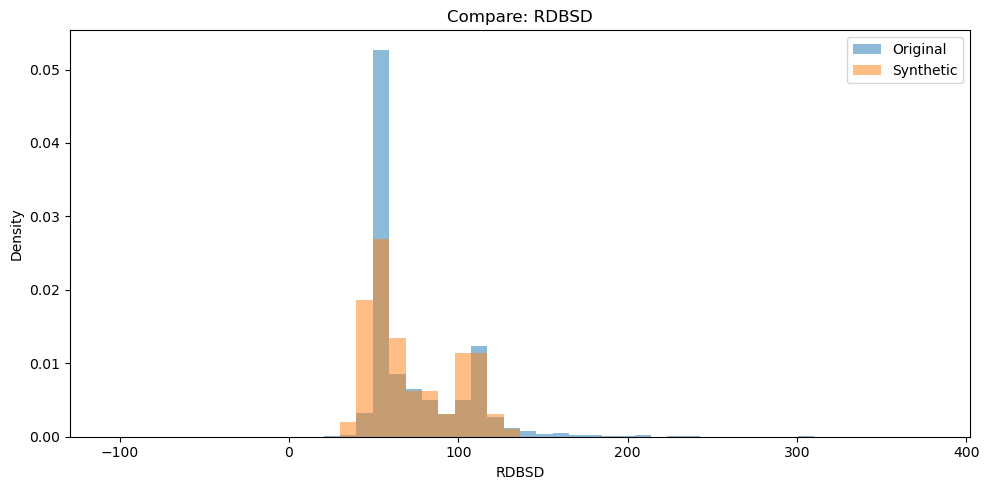

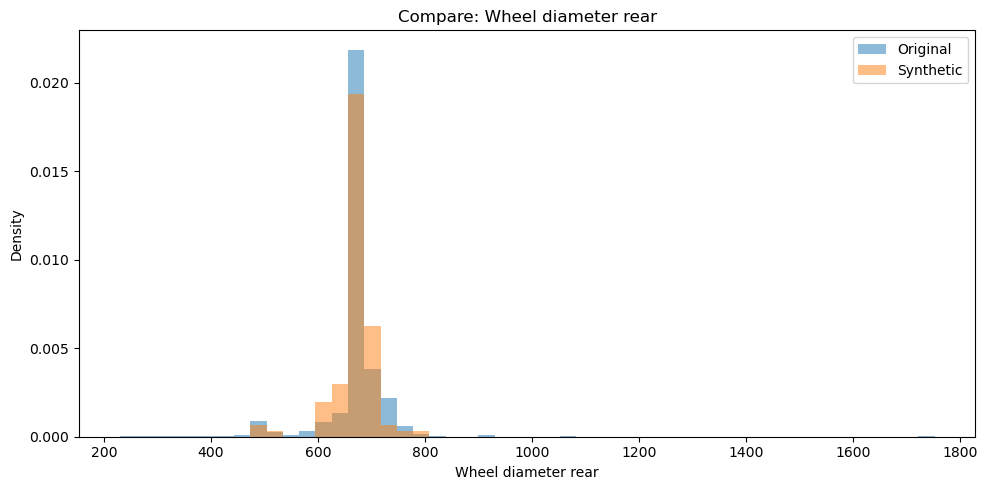

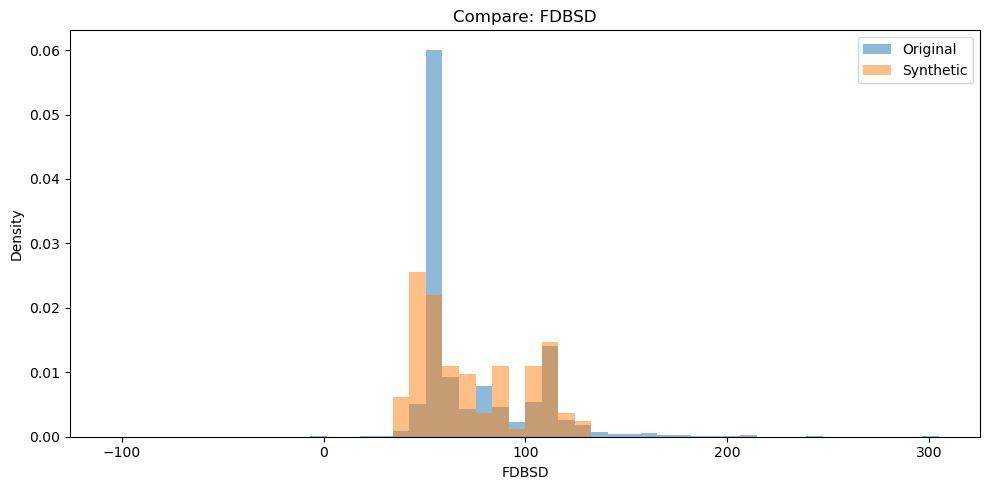

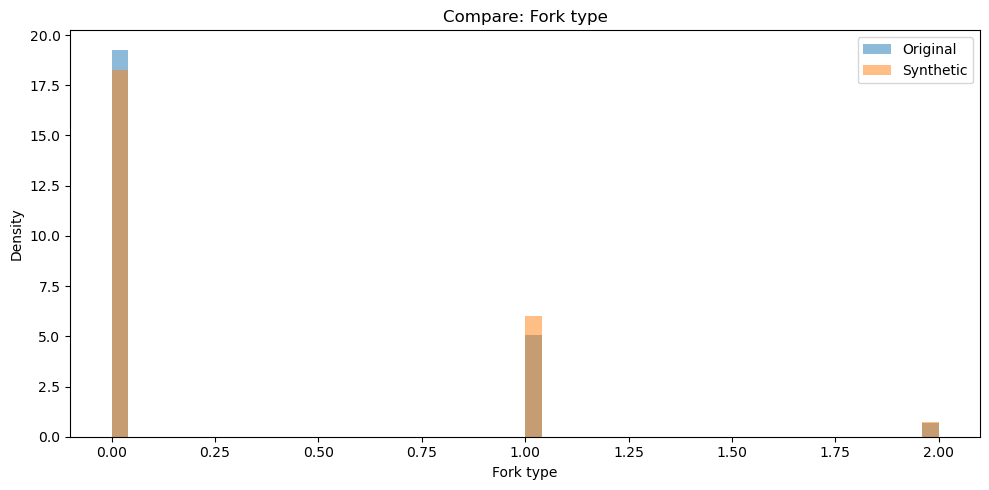

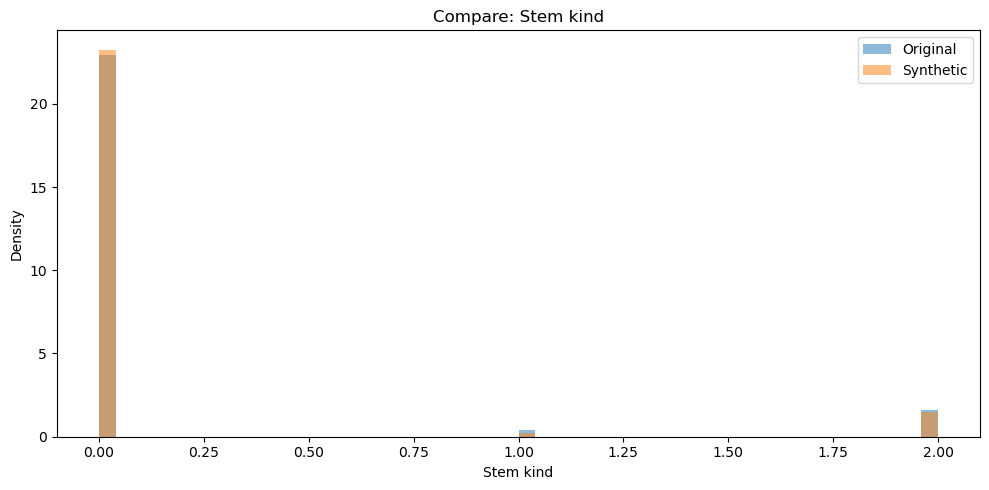

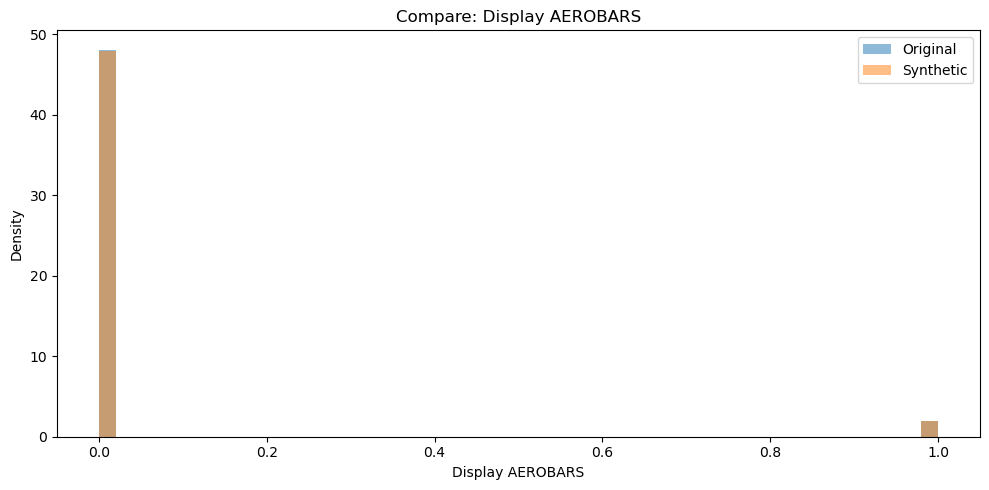

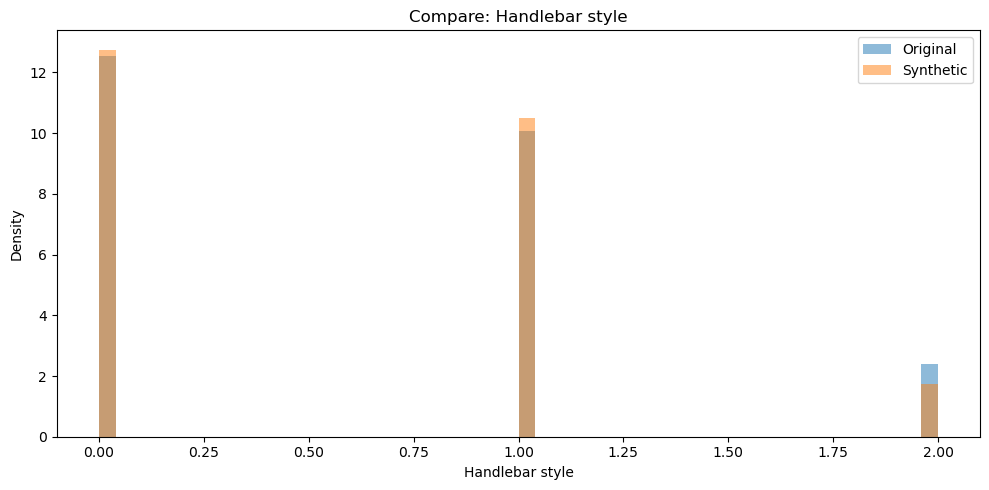

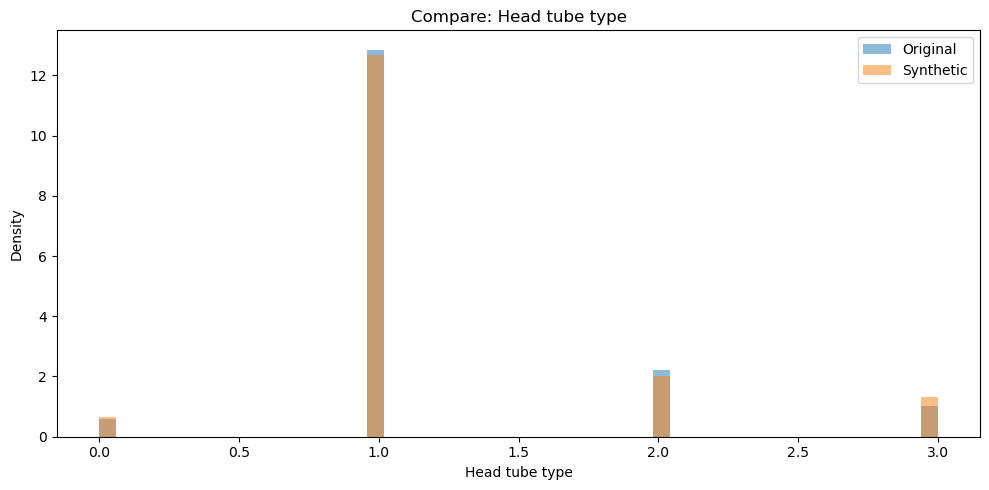

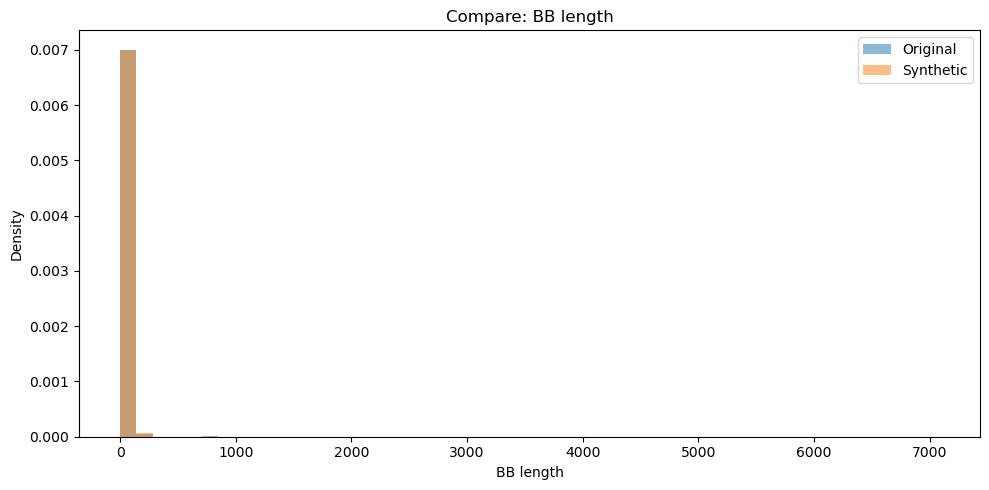

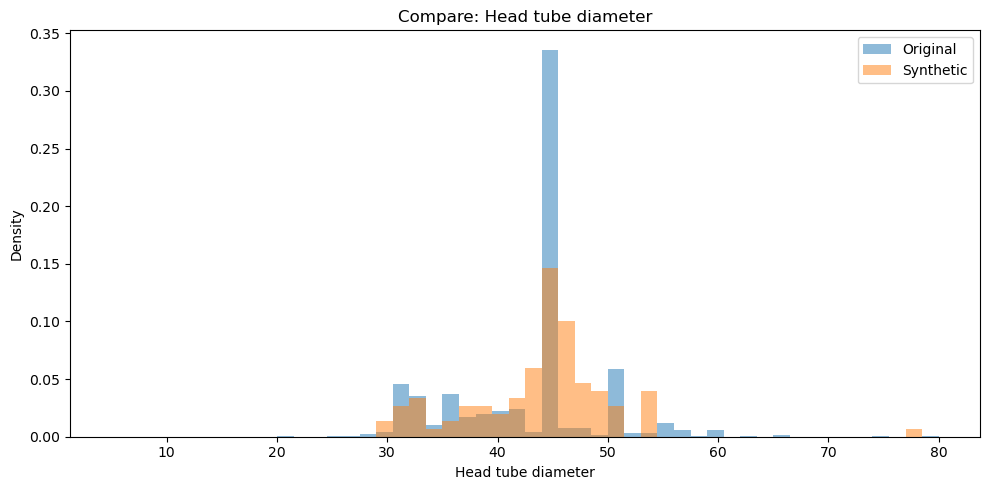

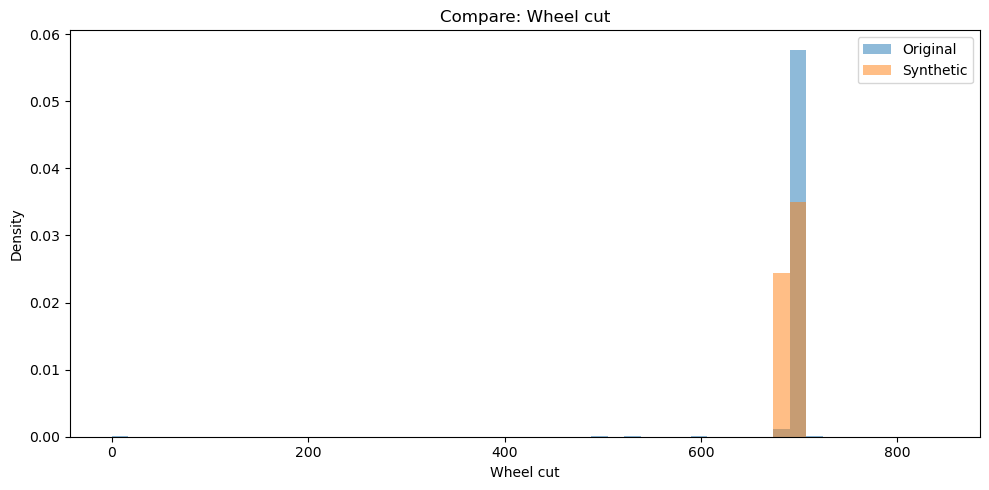

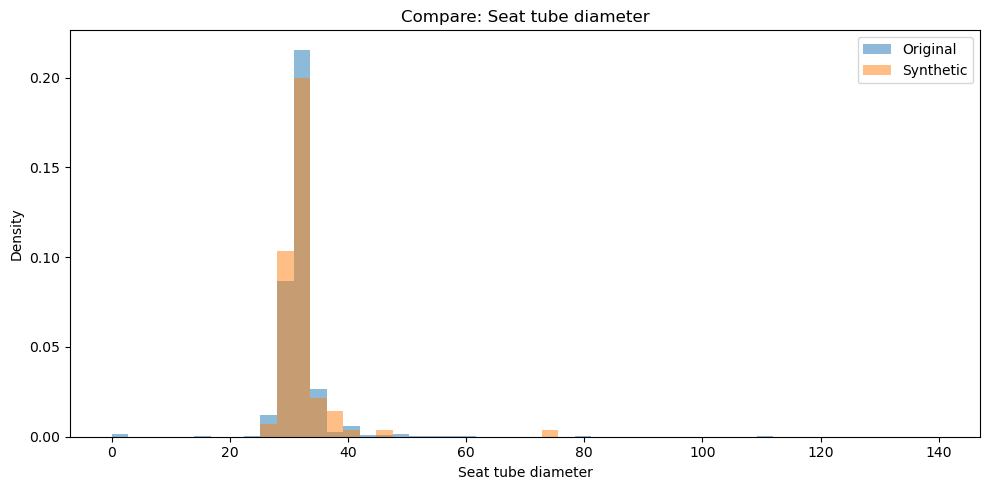

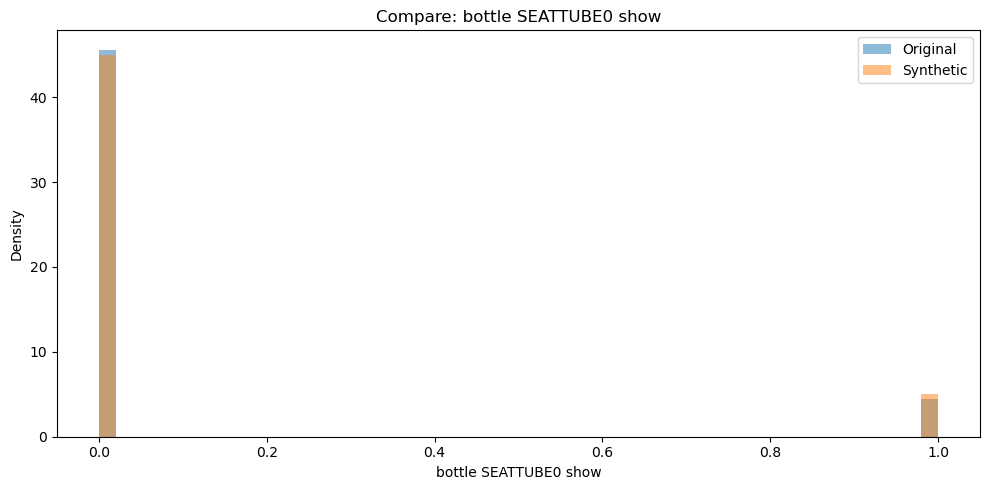

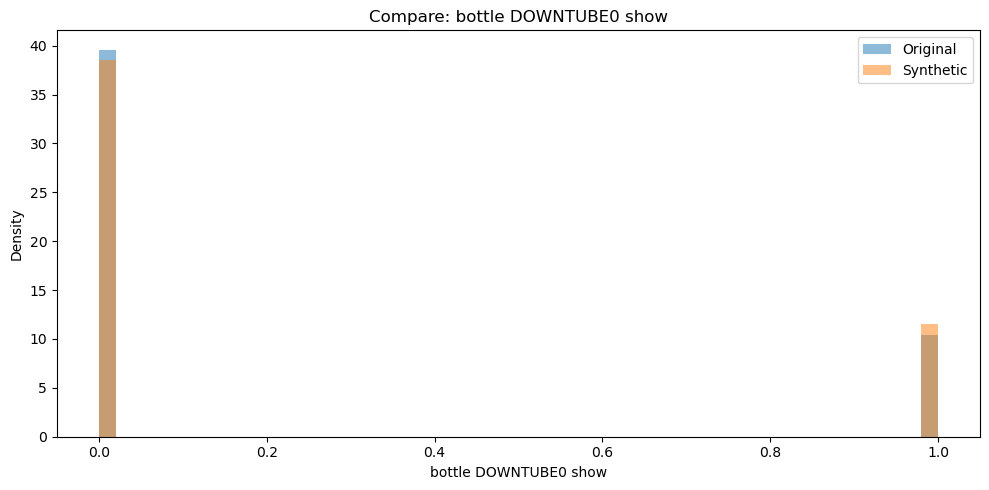

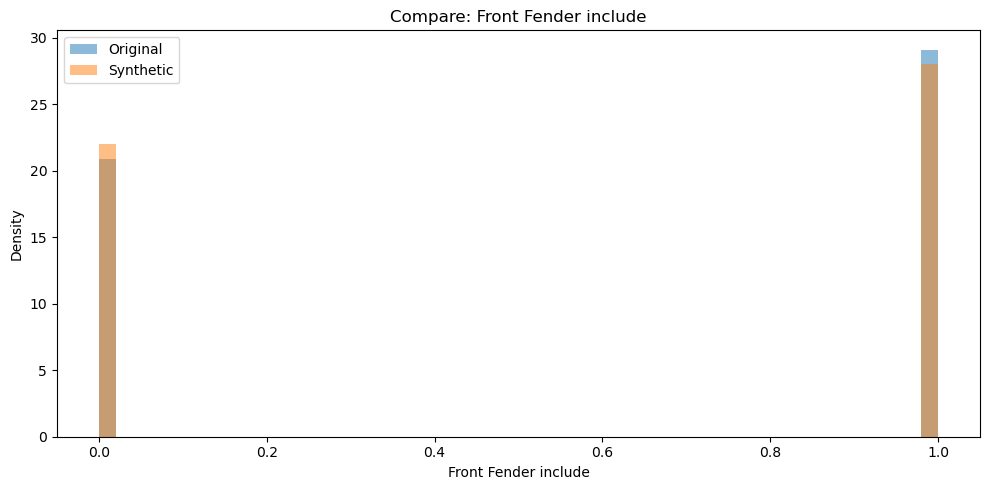

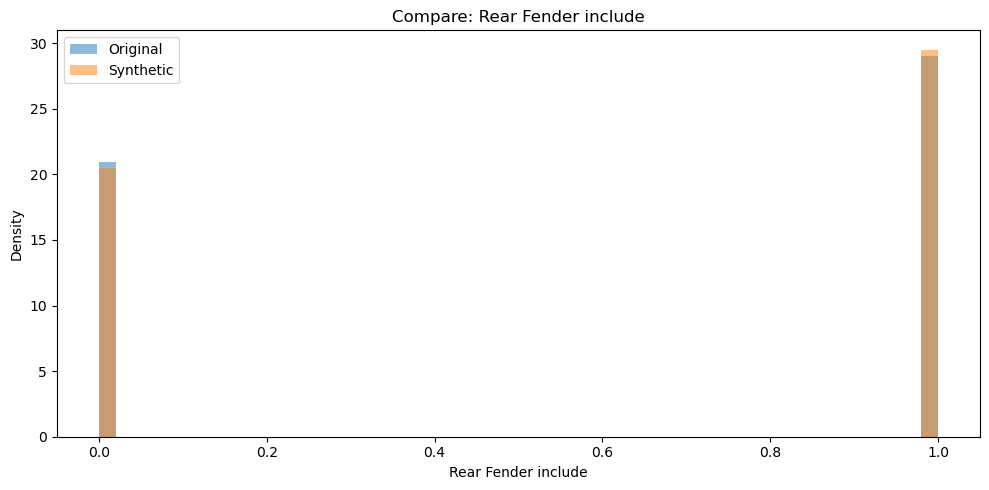

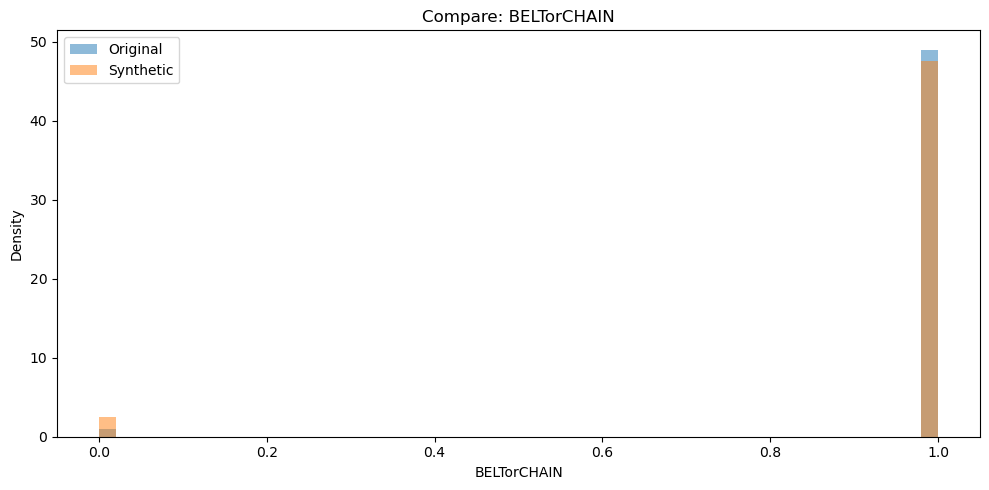

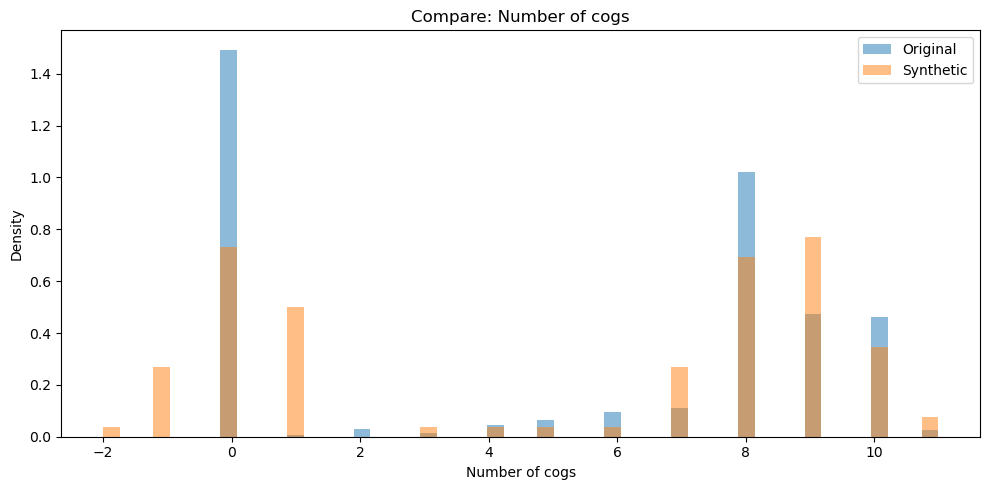

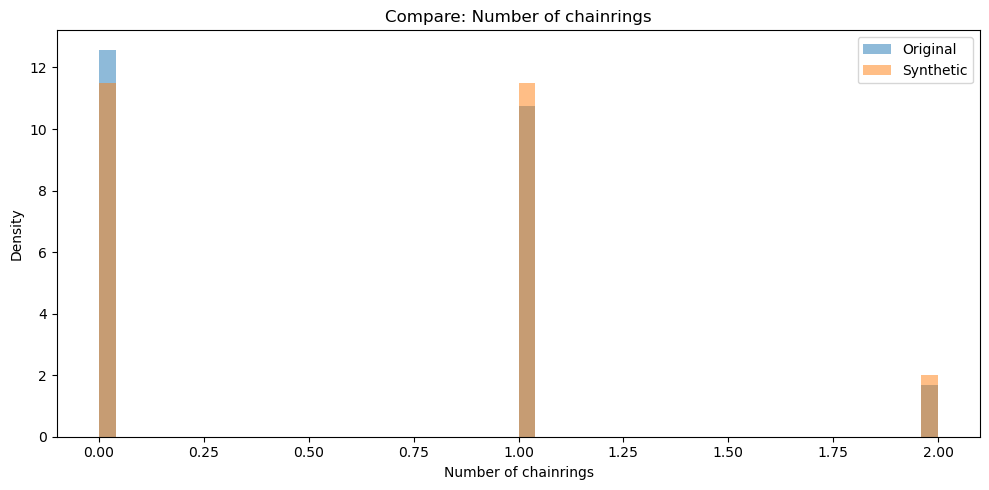

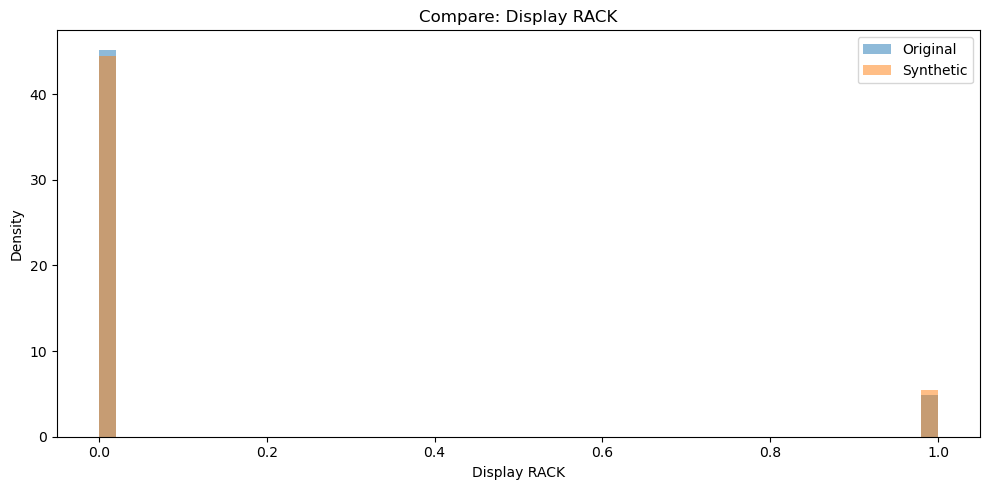

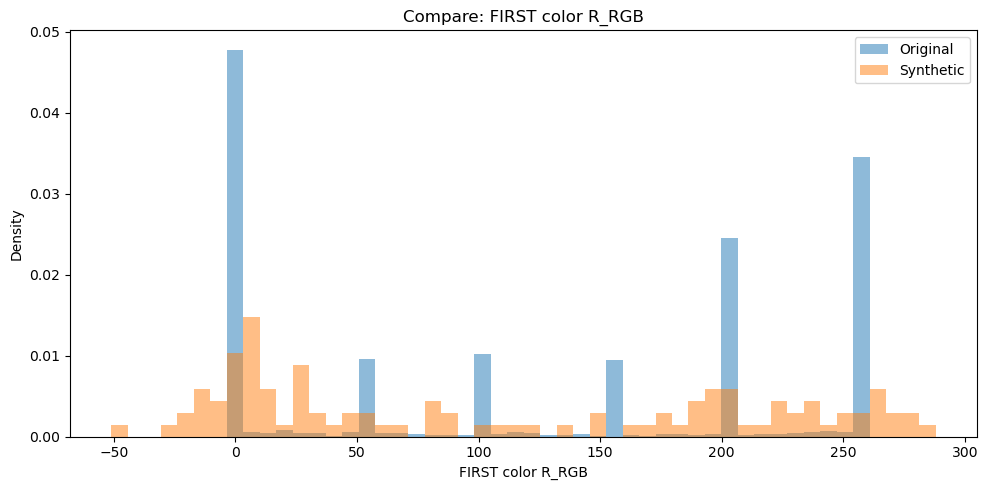

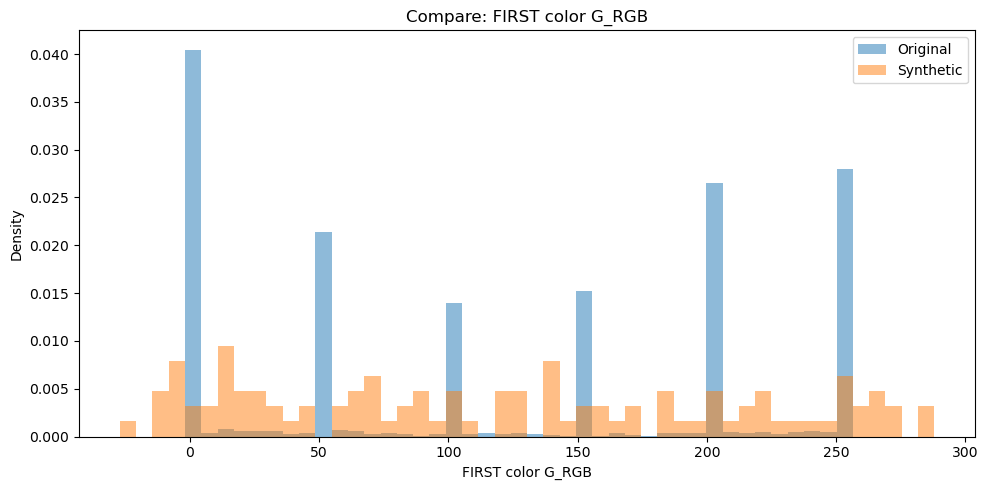

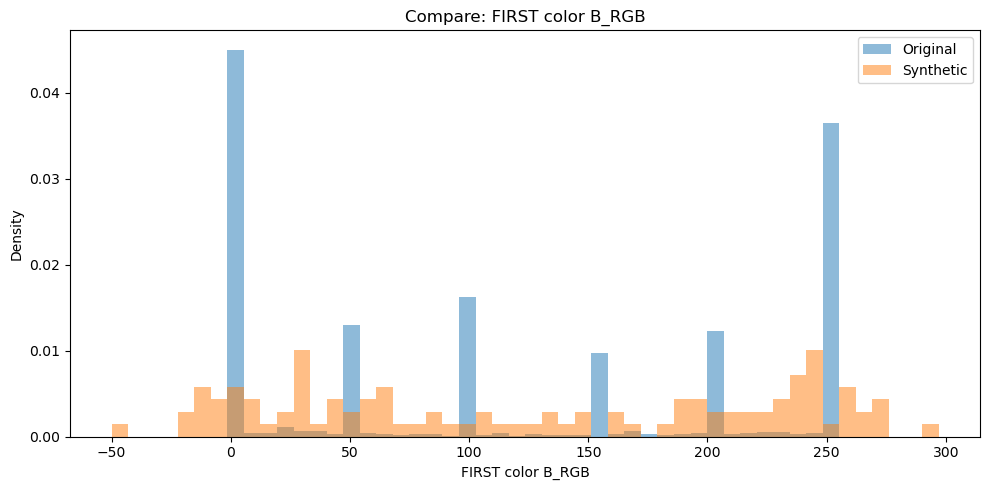

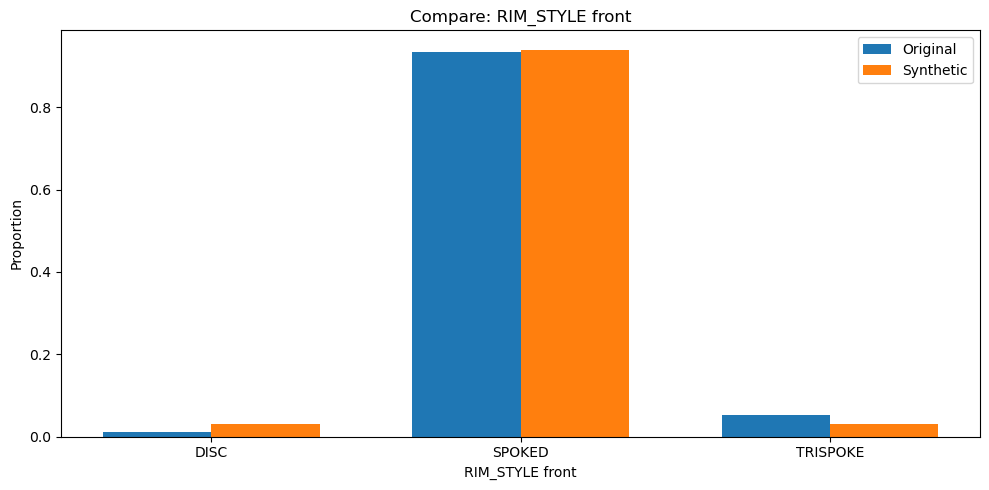

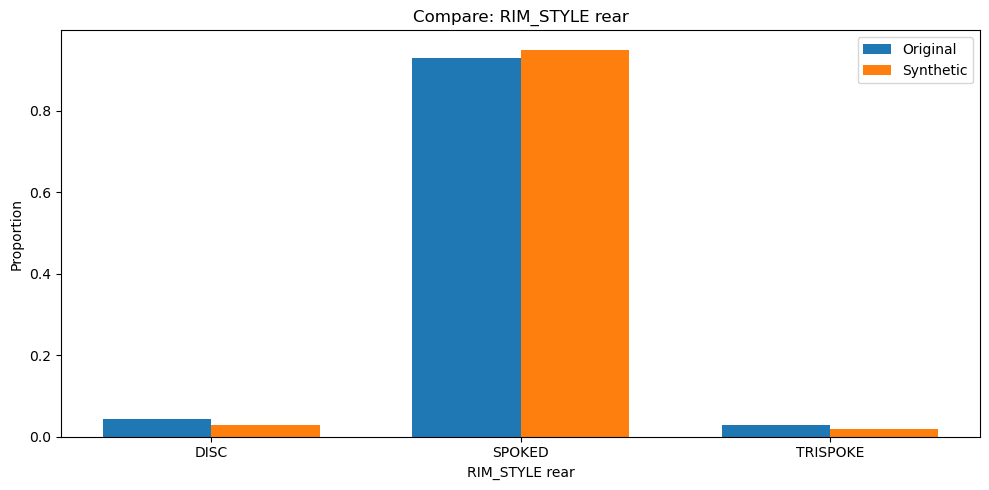

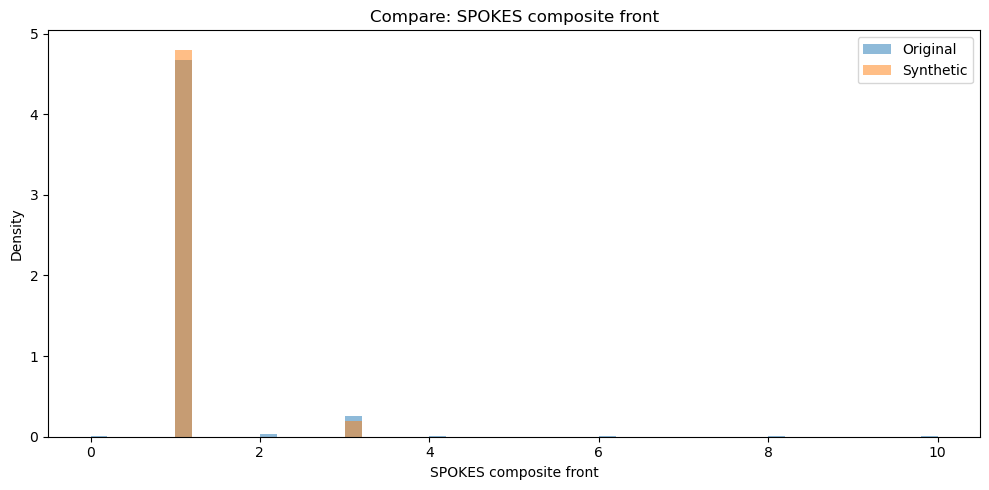

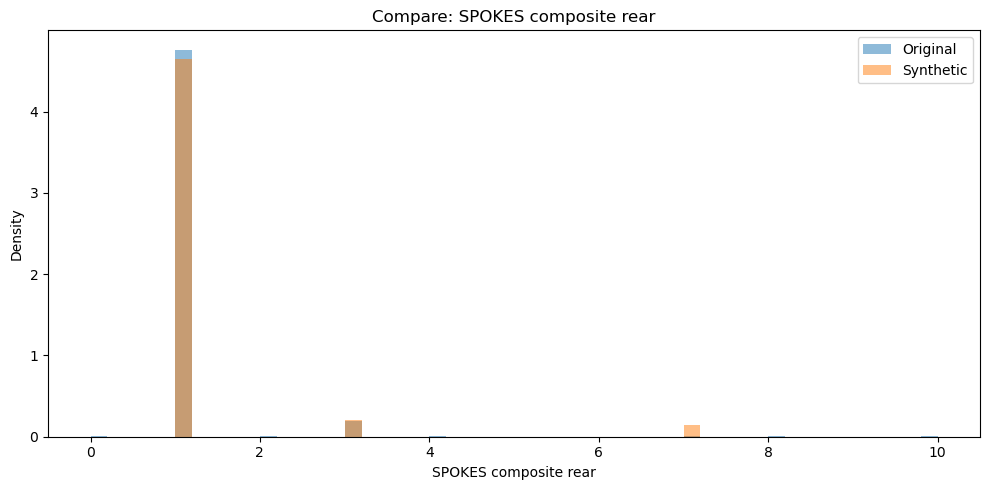

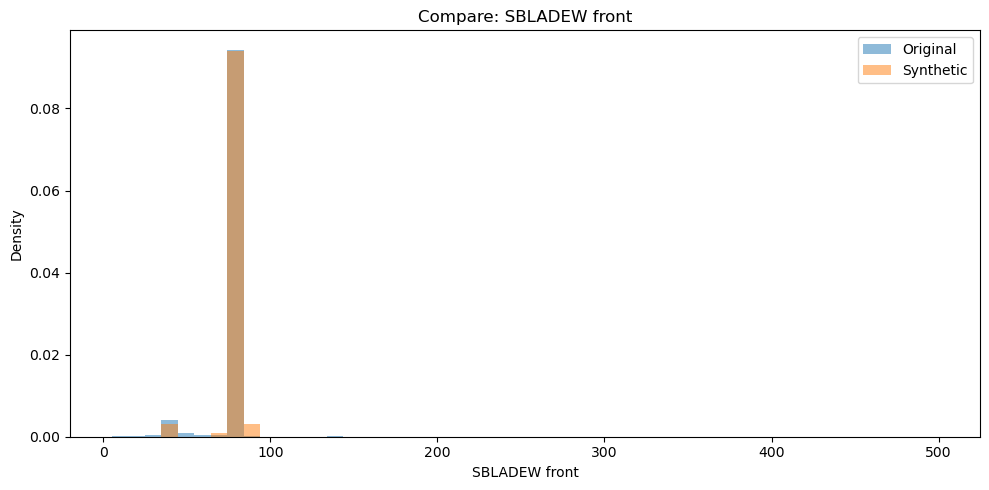

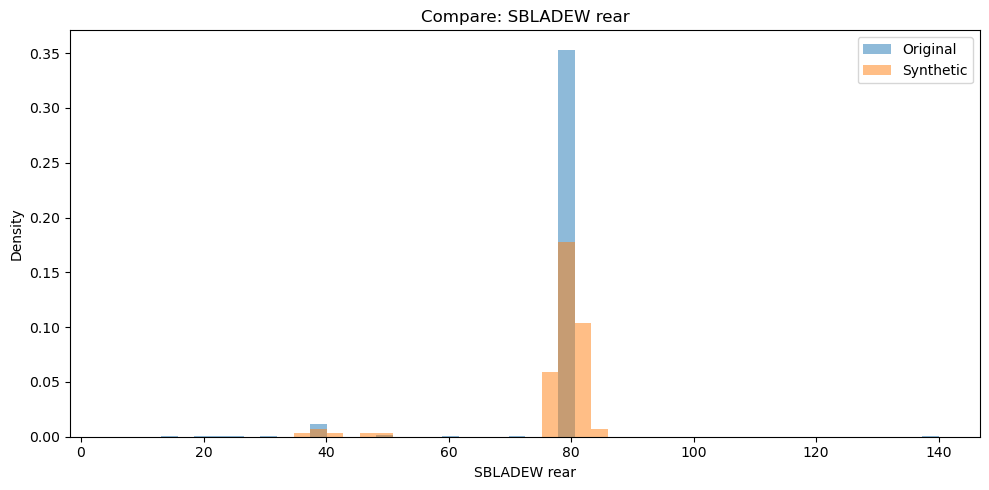

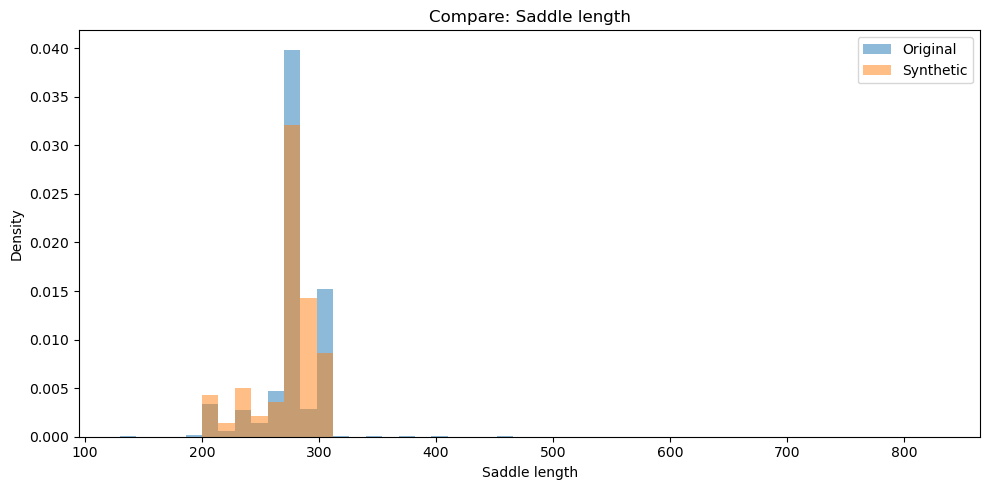

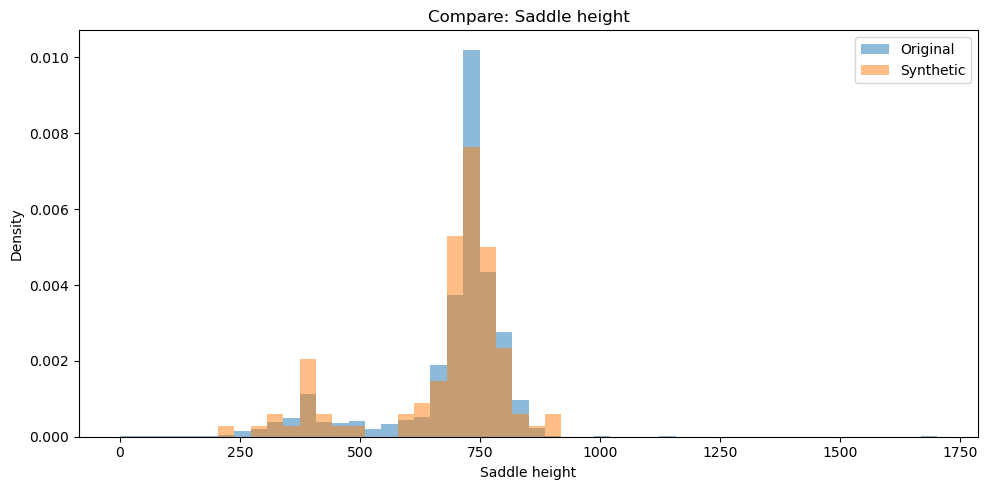

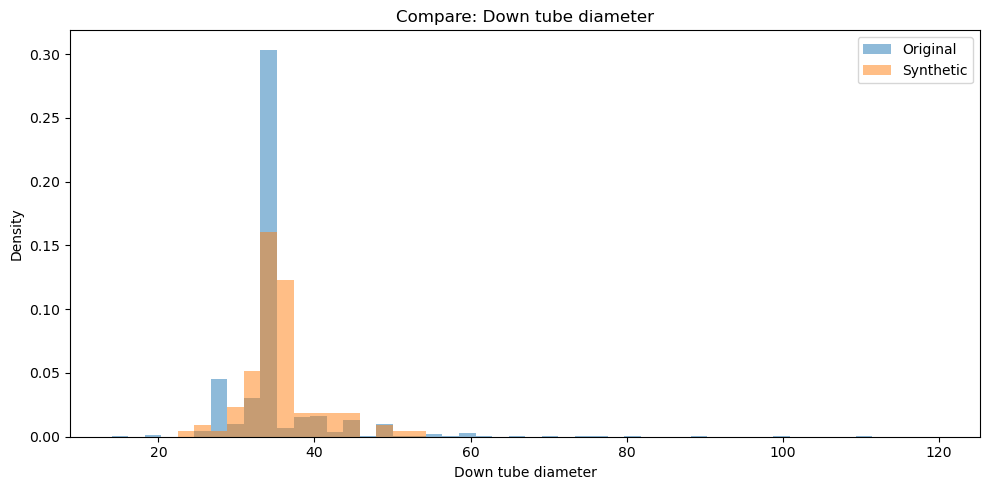

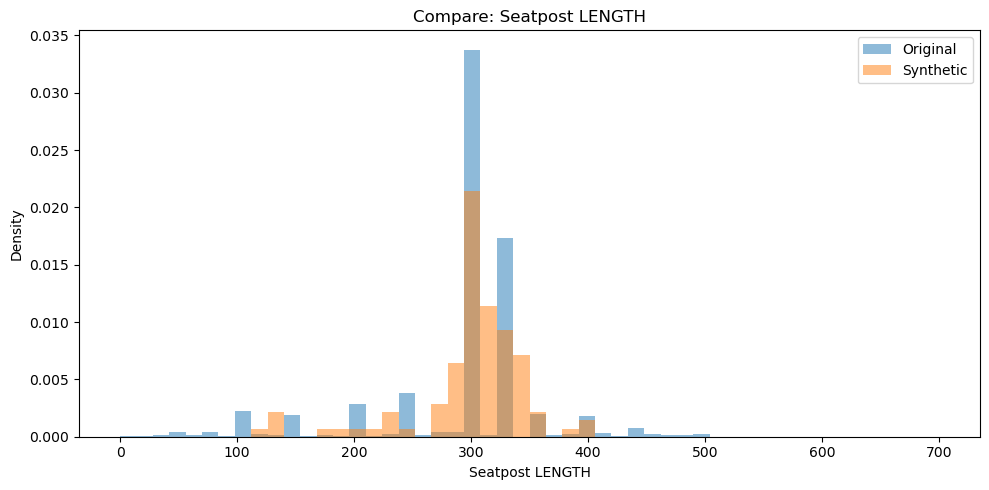

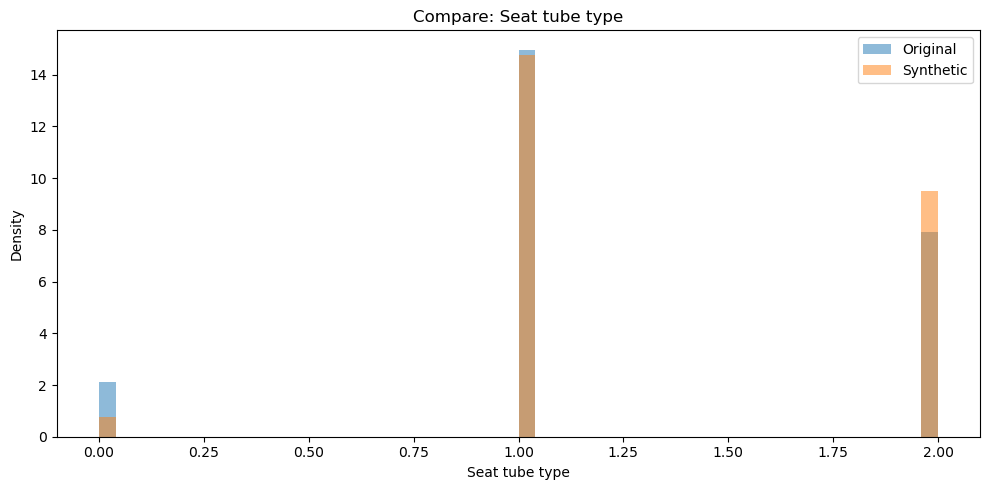

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_distributions(
    real_df: pd.DataFrame,
    synth_df: pd.DataFrame,
    numeric_bins: int = 50,
    figsize: tuple = (10, 5)
):
    """
    For each column in real_df / synth_df:
      - Numeric: overlaid, fixed‐width histograms
      - Categorical/boolean: side‐by‐side bar plots with equal bar width
    """
    for col in real_df.columns:
        plt.figure(figsize=figsize)
        real = real_df[col]
        synth = synth_df[col]

        # --- Numeric / ordinal columns ---
        if pd.api.types.is_numeric_dtype(real):
            # convert to numpy arrays
            r = real.dropna().to_numpy()
            s = synth.dropna().to_numpy()

            # common min/max & bins
            lo, hi = np.min([r.min(), s.min()]), np.max([r.max(), s.max()])
            bins = np.linspace(lo, hi, numeric_bins + 1)

            plt.hist(r, bins=bins, density=True, alpha=0.5, label='Original')
            plt.hist(s, bins=bins, density=True, alpha=0.5, label='Synthetic')
            plt.xlabel(col)
            plt.ylabel('Density')

        # --- Categorical or boolean columns ---
        else:
            # get normalized counts
            real_counts  = real.value_counts(normalize=True)
            synth_counts = synth.value_counts(normalize=True)

            # union of all categories / levels
            levels = sorted(set(real_counts.index) | set(synth_counts.index))

            # proportions in that order
            real_props  = [real_counts .get(l, 0) for l in levels]
            synth_props = [synth_counts.get(l, 0) for l in levels]

            # integer x positions & fixed bar width
            x = np.arange(len(levels))
            width = 0.35

            plt.bar(x - width/2, real_props,  width, label='Original')
            plt.bar(x + width/2, synth_props, width, label='Synthetic')

            # label ticks with the actual level names
            plt.xticks(x, [str(l) for l in levels])
            plt.xlabel(col)
            plt.ylabel('Proportion')

        plt.title(f'Compare: {col}')
        plt.legend()
        plt.tight_layout()
        plt.show()

compare_distributions(data, synthetic_collapsed, numeric_bins=50, figsize=(10, 5))